In [1]:
import numpy as np
X=np.load("E:/ADHD_EXP/unni/upsampled_ICA+DL_threshold_0.1178_power_6.npy")
Y=np.load("E:/ADHD_EXP/unni/upsampled_labels_1168.npy")

In [ ]:
import numpy as np
from scipy.linalg import sqrtm
import pygsp
import networkx as nx
from scipy.spatial.distance import cdist

# Parameters for distance-based thresholding
threshold = 2.2602  # threshold distance (in mm)
power = 4  # power parameter for Riemannian distance

# List to store the combined connectivity matrices
fc_matrix = []
eu_basis=[]
rem_basis=[]
cov_matrix=[]
combine_matrix=[]
projected_data=[]

for i in range(correlation_matrix.shape[0]):
   
    corr_matrix = correlation_matrix[i]
    # Construct the graph using distance-based thresholding
    adj_matrix = (abs(corr_matrix) < threshold).astype(int)
    graph = nx.from_numpy_array(adj_matrix)
   
    # Compute the graph Fourier basis using GSP
    G = pygsp.graphs.Graph(adj_matrix)
    G.compute_fourier_basis()
    fourier_basis = G.U.T
    eu_basis.append(fourier_basis)
    print("Eucl dimension: ", np.array(fourier_basis).shape)
    #print(fourier_basis)
    # Compute the Riemannian distance matrix and transform to Riemannian manifold
    cov_mat = np.cov(corr_matrix.T)
    cov_matrix.append(cov_mat)
    sqrt_cov_mat = sqrtm(cov_mat)
    inv_sqrt_cov_mat = np.linalg.inv(sqrt_cov_mat)
    riemannian_manifold= np.dot(inv_sqrt_cov_mat,cov_mat**power)
   
    # Compute the graph Laplacian and eigenvectors using Riemannian geometry
    riemannian_laplacian = np.eye(corr_matrix.shape[1]) - riemannian_manifold.T @ np.linalg.inv(riemannian_manifold @ riemannian_manifold.T) @ riemannian_manifold
    riemannian_eigvals, riemannian_eigvecs = np.linalg.eigh(riemannian_laplacian)
    riemannian_fourier_basis = riemannian_eigvecs.T
    rem_basis.append(riemannian_fourier_basis)
    print("rfb dimension: ", np.array(riemannian_fourier_basis).shape)
    #print(riemannian_fourier_basis)
    # Project the data onto the combined graph Fourier basis
    combined_fourier_basis = np.concatenate((fourier_basis, riemannian_fourier_basis), axis=1)
    combine_matrix.append(combined_fourier_basis)
    print("combined dimension: ", np.array(combined_fourier_basis).shape)
    proj_data = np.dot(corr_matrix, combined_fourier_basis)
    projected_data.append(proj_data)
    print("Projected dimension", np.array(proj_data).shape)
    print("\n");
   
    # Compute the combined functional connectivity matrix in the combined graph Fourier domain
    combined_matrix = np.corrcoef(proj_data)
    fc_matrix.append(combined_matrix)

In [49]:
X=np.load("E:/ADHD_EXP/unni/upsampled_ICA+DL_threshold_0.1178_power_6.npy")

In [51]:
X[0]

array([[1.        , 0.17569986, 0.01285523, ..., 0.08327486, 0.12430657,
        0.0864982 ],
       [0.17569986, 1.        , 0.97952001, ..., 0.97065879, 0.9657775 ,
        0.94562918],
       [0.01285523, 0.97952001, 1.        , ..., 0.96259428, 0.9477517 ,
        0.92948815],
       ...,
       [0.08327486, 0.97065879, 0.96259428, ..., 1.        , 0.92209804,
        0.91609841],
       [0.12430657, 0.9657775 , 0.9477517 , ..., 0.92209804, 1.        ,
        0.98710214],
       [0.0864982 , 0.94562918, 0.92948815, ..., 0.91609841, 0.98710214,
        1.        ]])

In [2]:
X=np.load("E:/ADHD_EXP/unni/upsampled_ICA+DL_threshold_0.1204_power_2.npy")

In [4]:
X[3]

array([[1.        , 0.99262247, 0.22990536, ..., 0.77052815, 0.70792751,
        0.83504736],
       [0.99262247, 1.        , 0.26982548, ..., 0.81077993, 0.71778408,
        0.83831446],
       [0.22990536, 0.26982548, 1.        , ..., 0.50473865, 0.25821817,
        0.42882525],
       ...,
       [0.77052815, 0.81077993, 0.50473865, ..., 1.        , 0.79588685,
        0.87806094],
       [0.70792751, 0.71778408, 0.25821817, ..., 0.79588685, 1.        ,
        0.91589586],
       [0.83504736, 0.83831446, 0.42882525, ..., 0.87806094, 0.91589586,
        1.        ]])

In [5]:
import numpy as np

# Assuming X is your 3D array with dimensions (a, b, b)
# Calculate the mean along the first axis
mean_fc_matrix_hgsa = np.mean(X, axis=0)

# Now mean_fc_matrix is a bxb matrix representing the mean functional connectivity matrix
overall_mean_value = np.mean(mean_fc_matrix_hgsa)

print("Mean FC matrix (HGSA):")
print(mean_fc_matrix_hgsa)
print("\nOverall mean value of mean_fc_matrix_hgsa:", overall_mean_value)

Mean FC matrix (HGSA):
[[1.         0.85950386 0.59967524 ... 0.69617551 0.7309345  0.72019647]
 [0.85950386 1.         0.60646182 ... 0.72697701 0.68390155 0.69694434]
 [0.59967524 0.60646182 1.         ... 0.57515408 0.59315255 0.60637929]
 ...
 [0.69617551 0.72697701 0.57515408 ... 1.         0.65493691 0.68856542]
 [0.7309345  0.68390155 0.59315255 ... 0.65493691 1.         0.80307128]
 [0.72019647 0.69694434 0.60637929 ... 0.68856542 0.80307128 1.        ]]

Overall mean value of mean_fc_matrix_hgsa: 0.6477597543894016


In [9]:
X=np.load("E:/ADHD200/feature_941.npy")
correlation_matrix=X

In [10]:
correlation_matrix.shape[0]

941

In [12]:
eu_basis[0]

array([[ 0.10369517,  0.10369517,  0.10369517, ...,  0.10369517,
         0.10369517,  0.10369517],
       [ 0.04687708,  0.69678428, -0.67346093, ...,  0.00391269,
         0.00110239,  0.00675922],
       [ 0.        ,  0.00496525,  0.00557017, ..., -0.01043951,
        -0.01608372,  0.03264942],
       ...,
       [ 0.        ,  0.00338824,  0.01697484, ...,  0.02332087,
         0.04963512,  0.0186118 ],
       [ 0.        , -0.00886864,  0.00707278, ..., -0.02928815,
         0.0102662 , -0.00504418],
       [ 0.        , -0.01067599, -0.01315929, ...,  0.00287582,
        -0.02155787, -0.08325594]])

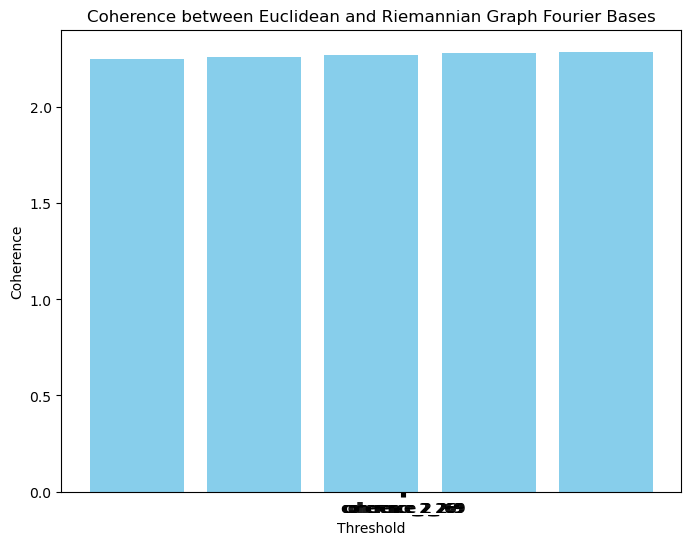

In [162]:
import numpy as np
import matplotlib.pyplot as plt

# Threshold values
thresholds = [2.25, 2.2602, 2.269, 2.279, 2.288]

# Coherence values for each threshold
coherences = ['coherence_2_25', 'coherence_2_2602', 'coherence_2_269', 'coherence_2_279', 'coherence_2_288']

# Sort coherence values based on thresholds
sorted_coherences = [coherences[thresholds.index(t)] for t in sorted(thresholds)]

# Plot the coherence values
plt.figure(figsize=(8, 6))
plt.bar(sorted_coherences, thresholds, color='skyblue')
plt.xlabel('Threshold')
plt.ylabel('Coherence')
plt.title('Coherence between Euclidean and Riemannian Graph Fourier Bases')
plt.xticks(thresholds)
plt.show()


In [126]:
fourier_basis

array([[-0.10369517, -0.10369517, -0.10369517, ..., -0.10369517,
        -0.10369517, -0.10369517],
       [ 0.        ,  0.00884314,  0.005476  , ...,  0.04240462,
        -0.15612528,  0.06330303],
       [ 0.        ,  0.00674518,  0.00404098, ..., -0.01637761,
         0.00234007, -0.0029688 ],
       ...,
       [ 0.        , -0.00306297, -0.02516956, ...,  0.01261029,
         0.08194315,  0.0678511 ],
       [ 0.        , -0.00344876, -0.00679389, ...,  0.09115421,
         0.07628012,  0.00693381],
       [ 0.        ,  0.00580175, -0.00362414, ..., -0.0219968 ,
         0.09987357, -0.0097119 ]])

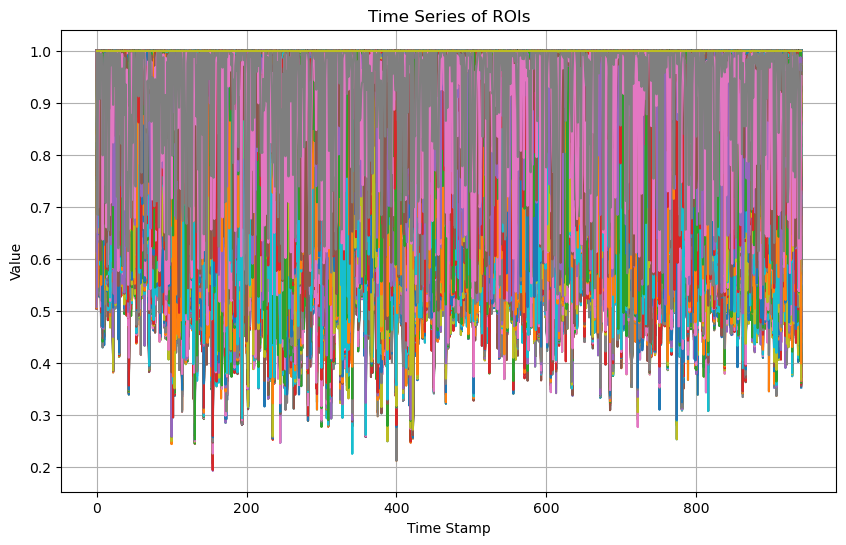

In [134]:
import numpy as np
import matplotlib.pyplot as plt

# Example data: a 10x5 matrix
a = np.array(fc_matrix).shape[0]  # Number of time stamps
b = np.array(fc_matrix).shape[1]    # Number of ROIs
time_series = np.array(fc_matrix)  # Replace this with your actual data

# Plotting
plt.figure(figsize=(10, 6))
for i in range(b):
    plt.plot(range(a), time_series[:, i], label=f'ROI {i+1}')

plt.title('Time Series of ROIs')
plt.xlabel('Time Stamp')
plt.ylabel('Value')
#plt.legend()
plt.grid(True)
plt.show()

In [127]:
riemannian_fourier_basis

array([[-0.03556074+0.00000000e+00j,  0.02047584-2.82743637e-05j,
        -0.08943492+1.63244994e-04j, ...,  0.06715623+6.44889770e-05j,
        -0.03158978-3.58459002e-06j, -0.18289648-1.79926296e-04j],
       [-0.0798775 +0.00000000e+00j,  0.02434201+1.36819814e-04j,
        -0.07351017-3.80841764e-04j, ...,  0.01080647-5.69906871e-04j,
         0.34744496+3.72526090e-04j,  0.18358466+9.07148659e-04j],
       [ 0.06324833+0.00000000e+00j,  0.02997646+3.04026621e-04j,
        -0.08546409-9.41375626e-04j, ..., -0.08279326-3.89760980e-04j,
        -0.35017289-2.14420505e-03j, -0.04210105+7.97864571e-05j],
       ...,
       [ 0.03190352+0.00000000e+00j, -0.02697126-3.22293055e-06j,
         0.12160694-2.18898361e-05j, ..., -0.06822061-4.43883041e-04j,
        -0.02202758-1.53751181e-05j,  0.23613375+1.09366065e-03j],
       [-0.09780692+0.00000000e+00j, -0.00614596-5.92433181e-05j,
         0.0055469 +1.95979932e-04j, ..., -0.15959944+4.30171030e-04j,
        -0.43320669+1.75549335e-04j

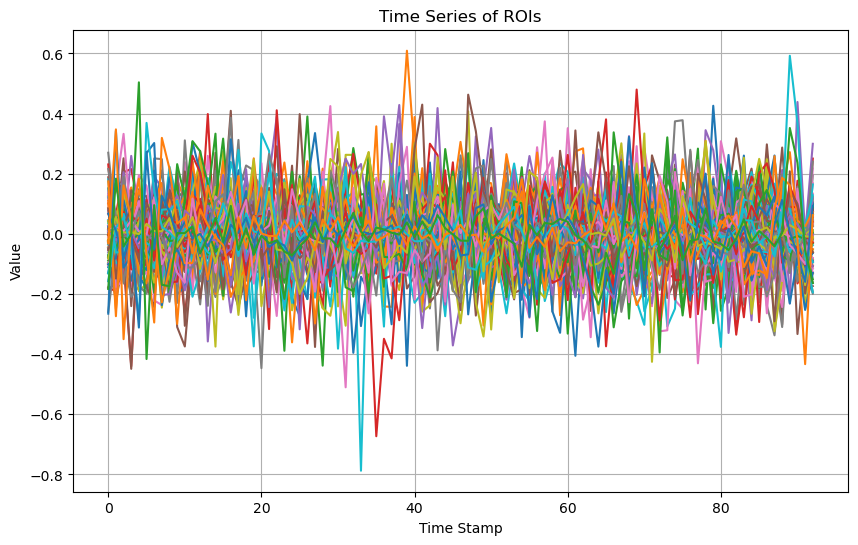

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# Example data: a 10x5 matrix
a = np.array(riemannian_fourier_basis).shape[0]  # Number of time stamps
b = np.array(riemannian_fourier_basis).shape[1]    # Number of ROIs
time_series = np.array(riemannian_fourier_basis)  # Replace this with your actual data

# Plotting
plt.figure(figsize=(10, 6))
for i in range(b):
    plt.plot(range(a), time_series[:, i], label=f'ROI {i+1}')

plt.title('Time Series of ROIs')
plt.xlabel('Time Stamp')
plt.ylabel('Value')
#plt.legend()
plt.grid(True)
plt.show()

In [128]:
combined_fourier_basis

array([[-0.10369517+0.00000000e+00j, -0.10369517+0.00000000e+00j,
        -0.10369517+0.00000000e+00j, ..., -0.10369517+0.00000000e+00j,
        -0.10369517+0.00000000e+00j, -0.10369517+0.00000000e+00j],
       [ 0.        +0.00000000e+00j,  0.00884314+0.00000000e+00j,
         0.005476  +0.00000000e+00j, ...,  0.04240462+0.00000000e+00j,
        -0.15612528+0.00000000e+00j,  0.06330303+0.00000000e+00j],
       [ 0.        +0.00000000e+00j,  0.00674518+0.00000000e+00j,
         0.00404098+0.00000000e+00j, ..., -0.01637761+0.00000000e+00j,
         0.00234007+0.00000000e+00j, -0.0029688 +0.00000000e+00j],
       ...,
       [ 0.03190352+0.00000000e+00j, -0.02697126-3.22293055e-06j,
         0.12160694-2.18898361e-05j, ..., -0.06822061-4.43883041e-04j,
        -0.02202758-1.53751181e-05j,  0.23613375+1.09366065e-03j],
       [-0.09780692+0.00000000e+00j, -0.00614596-5.92433181e-05j,
         0.0055469 +1.95979932e-04j, ..., -0.15959944+4.30171030e-04j,
        -0.43320669+1.75549335e-04j

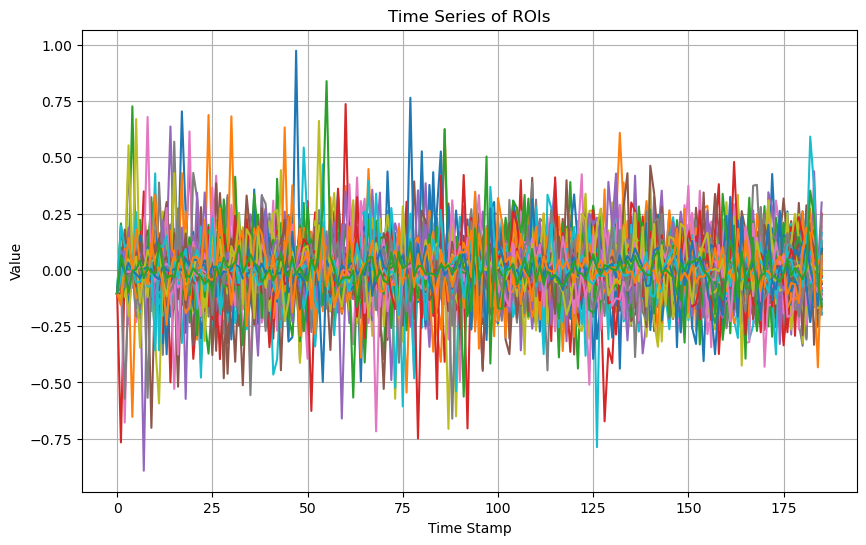

In [131]:
import numpy as np
import matplotlib.pyplot as plt

# Example data: a 10x5 matrix
a = np.array(combined_fourier_basis).shape[0]  # Number of time stamps
b = np.array(combined_fourier_basis).shape[1]    # Number of ROIs
time_series = np.array(combined_fourier_basis)  # Replace this with your actual data

# Plotting
plt.figure(figsize=(10, 6))
for i in range(b):
    plt.plot(range(a), time_series[:, i], label=f'ROI {i+1}')

plt.title('Time Series of ROIs')
plt.xlabel('Time Stamp')
plt.ylabel('Value')
#plt.legend()
plt.grid(True)
plt.show()


In [129]:
proj_data

array([[-6.88027219e+00+0.00000000e+00j,  4.44886409e-01+0.00000000e+00j,
        -2.40460718e-01+0.00000000e+00j, ...,
         9.00702968e-02+1.36868529e-06j, -5.87082351e+00-3.63001415e-04j,
         1.11576781e+00-9.96143564e-03j],
       [-4.40562165e+00+0.00000000e+00j, -1.11037546e-01+0.00000000e+00j,
         2.89000842e-02+0.00000000e+00j, ...,
         1.00854993e-01+3.62530817e-05j, -3.23431799e+00+1.83706021e-04j,
         7.48852719e-01-5.26103709e-03j],
       [-1.76108843e+00+0.00000000e+00j, -3.20462970e-01+0.00000000e+00j,
        -4.71602346e-03+0.00000000e+00j, ...,
         3.42689936e-01+2.90871240e-04j, -5.95081021e-01-5.35283833e-04j,
        -2.17564236e-01-1.73881686e-03j],
       ...,
       [-7.04243782e+00+0.00000000e+00j,  4.78718335e-01+0.00000000e+00j,
        -1.81370939e-01+0.00000000e+00j, ...,
         1.11655484e-01+5.00125749e-05j, -6.02109565e+00-3.14380978e-04j,
         1.17613092e+00-1.00892316e-02j],
       [-7.26396712e+00+0.00000000e+00j,  3.

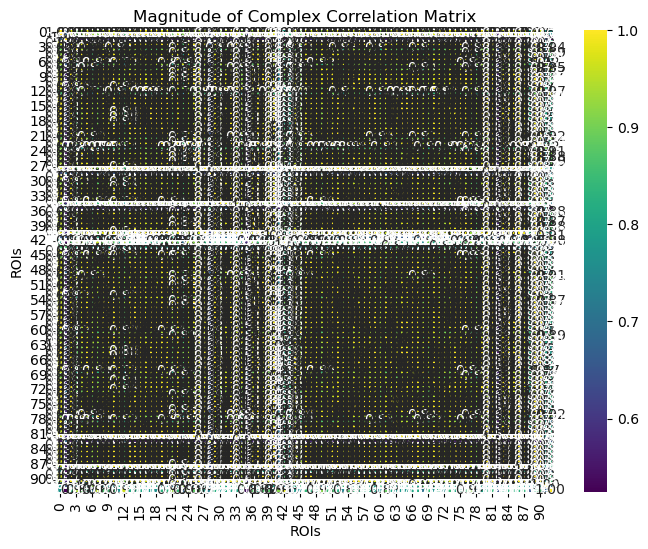

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample complex-valued correlation matrix
correlation_matrix_complex = np.array(fc_matrix[1])

# Compute magnitude of complex values
magnitude_matrix = np.abs(correlation_matrix_complex)

# Plot heatmap of magnitude
plt.figure(figsize=(8, 6))
sns.heatmap(magnitude_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Magnitude of Complex Correlation Matrix')
plt.xlabel('ROIs')
plt.ylabel('ROIs')
plt.show()


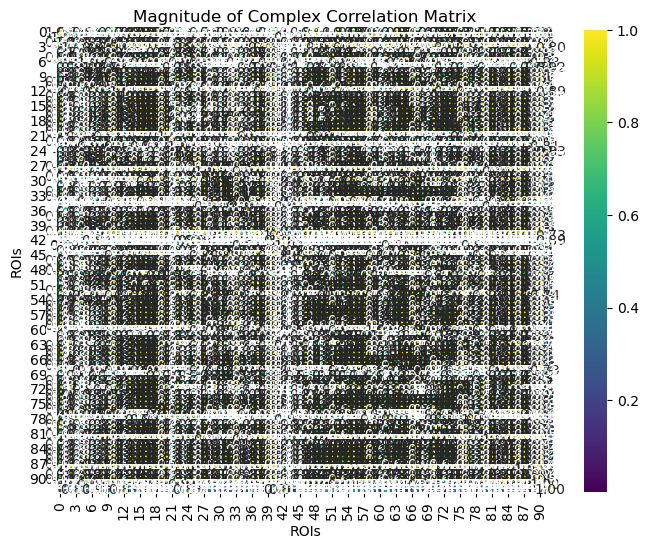

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample complex-valued correlation matrix
correlation_matrix_complex = np.array(X[1])

# Compute magnitude of complex values
magnitude_matrix = np.abs(correlation_matrix_complex)

# Plot heatmap of magnitude
plt.figure(figsize=(8, 6))
sns.heatmap(magnitude_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Magnitude of Complex Correlation Matrix')
plt.xlabel('ROIs')
plt.ylabel('ROIs')
plt.show()

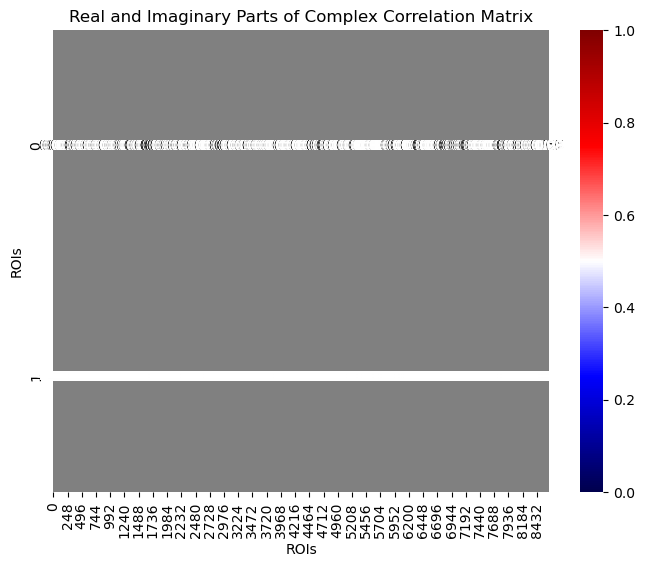

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample complex-valued correlation matrix
correlation_matrix_complex = np.array(fc_matrix[6])

# Separate real and imaginary parts
real_part = np.real(correlation_matrix_complex)
imaginary_part = np.imag(correlation_matrix_complex)

# Create a combined matrix by stacking the real and imaginary parts
combined_matrix = np.stack((real_part, imaginary_part))

# Flatten the combined matrix
flattened_matrix = np.concatenate(combined_matrix)

# Reshape the flattened matrix to 2D
flattened_matrix_2d = flattened_matrix.reshape(2, -1)

# Plot heatmap of the combined matrix
plt.figure(figsize=(8, 6))
sns.heatmap(flattened_matrix_2d, annot=True, cmap='seismic', fmt=".2f", linewidths=0.5, linecolor='gray')
plt.title('Real and Imaginary Parts of Complex Correlation Matrix')
plt.xlabel('ROIs')
plt.ylabel('ROIs')
plt.show()


Fold 1/5
Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_6 (Conv1D)           (None, 8649, 32)          128       
                                                                 
 dropout (Dropout)           (None, 8649, 32)          0         
                                                                 
 max_pooling1d_5 (MaxPooling  (None, 4324, 32)         0         
 1D)                                                             
                                                                 
 conv1d_7 (Conv1D)           (None, 4324, 64)          6208      
                                                                 
 dropout_1 (Dropout)         (None, 4324, 64)          0         
                                                                 
 max_pooling1d_6 (MaxPooling  (None, 2162, 64)         0         
 1D)                                        

C:\Users\hp\AppData\Local\Temp\ipykernel_2172\3333733375.py:80: RuntimeWarning: invalid value encountered in longlong_scalars
  precision = tp / (tp + fp)


48/48 [==============================] - 28s 567ms/step - loss: 0.6713 - accuracy: 0.6202 - val_loss: 0.6702 - val_accuracy: 0.6223
Epoch 2/10
48/48 [==============================] - 26s 546ms/step - loss: 0.6704 - accuracy: 0.6202 - val_loss: 0.6693 - val_accuracy: 0.6223
Epoch 3/10
29/48 [=================>............] - ETA: 11s - loss: 0.6678 - accuracy: 0.6272

KeyboardInterrupt: 

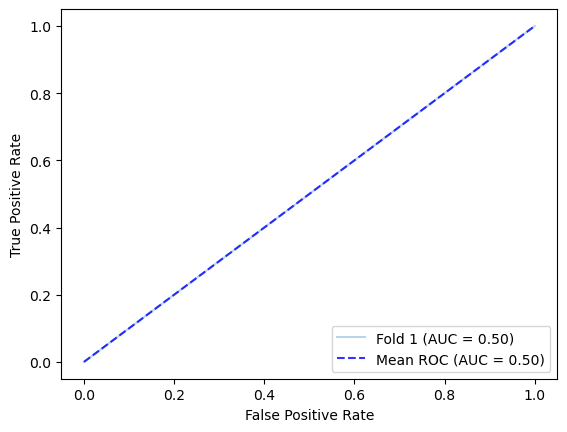

In [108]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
X=np.array(fc_matrix)
Y=np.load("E:\ADHD200\label_941.npy")
X=np.reshape(X,(X.shape[0],X.shape[1]*X.shape[2]))
# Preprocess the data as needed, such as normalization or rescaling
input_shape = (X.shape[1], 1)
# Define the model architecture
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(X.shape[1], 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
# Define the k-fold cross-validation
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
# Define the lists to store the results
auc_scores = []
precisions=[]
sensitivities=[]
specificities=[]
accuracies=[]
tprs=[]

acc_scores = []
val_acc_scores = []
loss_scores = []
val_loss_scores = []

mean_fpr = np.linspace(0, 1, 100)

# Train and evaluate the model using k-fold cross-validation and ROC curves
for fold, (train_idx, val_idx) in enumerate(skf.split(X, Y)):
    print(f"Fold {fold + 1}/{k}")
    
    # Split the data into training and validation sets
    X_train, y_train = X[train_idx], Y[train_idx]
    X_val, y_val = X[val_idx], Y[val_idx]
    
    # Reshape the data for the Conv1D layer
    X_train = np.expand_dims(X_train, axis=-1)
    X_val = np.expand_dims(X_val, axis=-1)
    
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()
    history=model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_val, y_val))
    acc_scores.append(history.history['accuracy'])
    val_acc_scores.append(history.history['val_accuracy'])
    loss_scores.append(history.history['loss'])
    val_loss_scores.append(history.history['val_loss'])
    
    # Calculate the predicted probabilities and ROC curve
    y_pred_prob = model.predict(X_val)
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    auc_score = roc_auc_score(y_val, y_pred_prob)
    auc_scores.append(auc_score)
    
    # Interpolate the ROC curve to the mean FPR
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    y_pred = np.where(y_pred_prob > 0.5, 1, 0)
    conf_matrix = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    precision = tp / (tp + fp)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    tprs.append(tpr)
    #aucs.append(roc_auc)
    precisions.append(precision)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    accuracies.append(accuracy)
    # Plot the ROC curve
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold + 1} (AUC = {auc_score:.2f})")
    plt.plot(mean_fpr, interp_tpr, alpha=0.8, label=f"Mean ROC (AUC = {np.mean(auc_scores):.2f})", color='b', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')

#mean_tpr = np.mean(tprs, axis=0)
#std_tpr = np.std(tprs, axis=0)
mean_precision = np.mean(precisions)
std_precision = np.std(precisions)
mean_sensitivity = np.mean(sensitivities)
std_sensitivity = np.std(sensitivities)
mean_specificity = np.mean(specificity)
std_specificity = np.std(specificity)
mean_accuracy  = np.mean(accuracies)
std_accuracy  = np.std(accuracies)
    # Print the average AUC score over all folds
print(f"Mean AUC score: {np.mean(auc_scores):.2f}")
print("Precision : ", mean_precision, '(+/-)' , std_precision)
print("Sensitivity : ",mean_sensitivity, '(+/-)' , std_sensitivity)
print("Specificity : ",mean_specificity, '(+/-)' , std_specificity)
print("Accuracy : ",mean_accuracy, '(+/-)' , std_accuracy)
# Save the plot
plt.savefig('roc_curve.png')

fig, axs = plt.subplots(2, k, figsize=(15, 5))
for i in range(k):
    axs[0,i].plot(acc_scores[i], label='Training accuracy')
    axs[0,i].plot(val_acc_scores[i], label='Validation accuracy')
    axs[0,i].set_title(f'Fold {i+1} accuracy')
    axs[0,i].legend()
    axs[1,i].plot(loss_scores[i], label='Training loss')
    axs[1,i].plot(val_loss_scores[i], label='Validation loss')
    axs[1,i].set_title(f'Fold {i+1} loss')
    axs[1,i].legend()

plt.tight_layout()
plt.show()

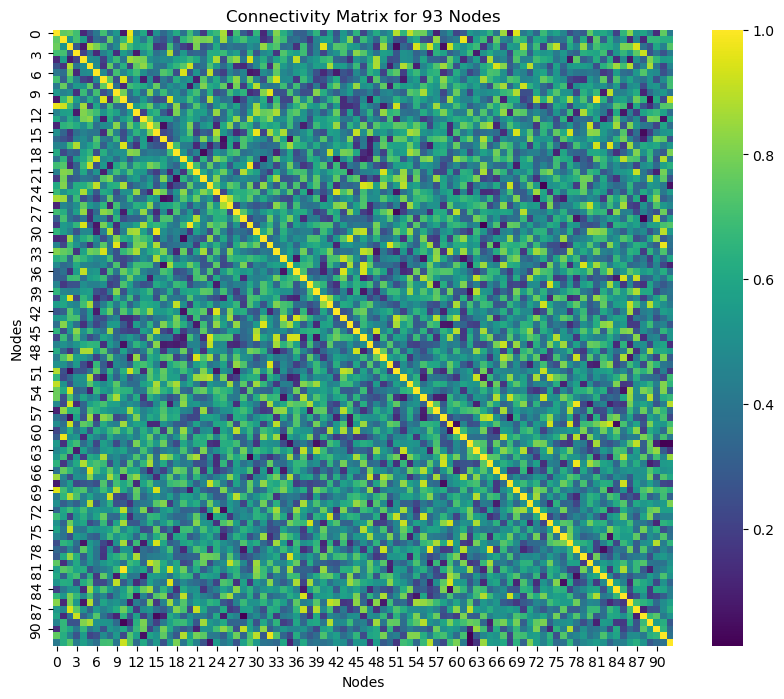

In [137]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a connectivity matrix 'conn_matrix' for 93 nodes
# Here we create a mock connectivity matrix for demonstration
np.random.seed(42)
conn_matrix = np.random.rand(93, 93)
conn_matrix = (conn_matrix + conn_matrix.T) / 2  # Make it symmetric
np.fill_diagonal(conn_matrix, 1)  # Optional: Fill diagonal to mark self-connections

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(conn_matrix, cmap='viridis')
plt.title('Connectivity Matrix for 93 Nodes')
plt.xlabel('Nodes')
plt.ylabel('Nodes')
plt.show()


C:\ProgramData\Anaconda3\lib\site-packages\scipy\signal\_spectral_py.py:1999: UserWarning: nperseg = 256 is greater than input length  = 100, using nperseg = 100
  warnings.warn('nperseg = {0:d} is greater than input length '


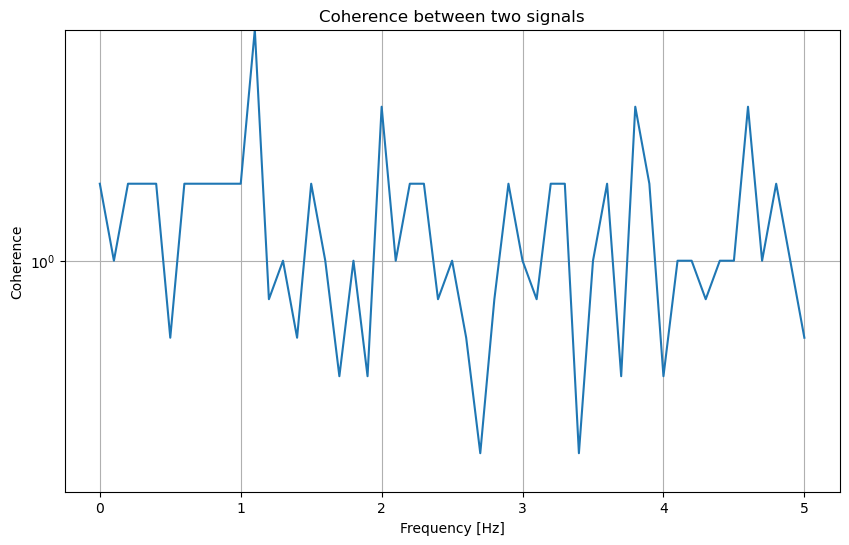

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import coherence

# Generate sample data: two signals with some degree of correlation
np.random.seed(0)
time = np.arange(0, 10, 0.1)
signal1 = np.sin(time) + np.random.normal(0, 0.5, len(time))
signal2 = np.sin(time + np.pi/4) + np.random.normal(0, 0.5, len(time))

# Calculate coherence
frequencies, coh = coherence(signal1, signal2, fs=10, nperseg=256)

# Plot coherence
plt.figure(figsize=(10, 6))
plt.semilogy(frequencies, coh)
plt.title('Coherence between two signals')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Coherence')
plt.grid(True)
plt.show()


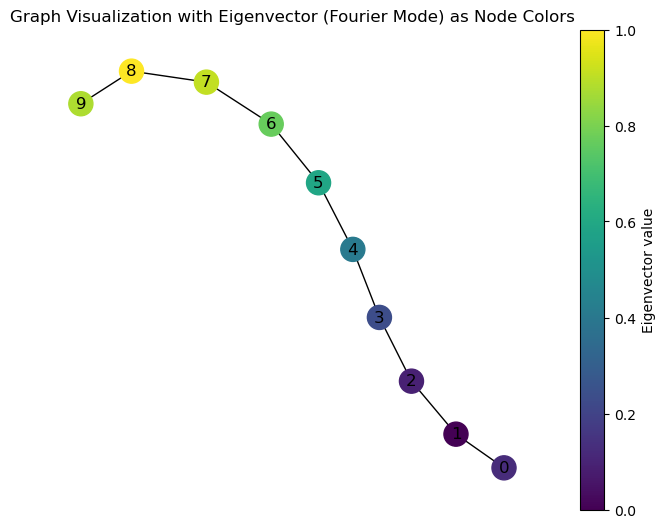

In [145]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
# Create a simple graph
G = nx.path_graph(10)  # A path graph for simplicity
# Calculate the normalized Laplacian matrix
L = nx.normalized_laplacian_matrix(G).toarray()
# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(L)
# Choose an eigenvector to visualize, e.g., the second-lowest frequency mode
eigenvector_to_visualize = eigenvectors[:, 1]
# Visualize the graph with the eigenvector values as node colors
pos = nx.spring_layout(G)  # Position nodes using the spring layout
nx.draw(G, pos, with_labels=True, node_color=eigenvector_to_visualize, cmap='viridis', node_size=300)
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), label='Eigenvector value')
plt.title('Graph Visualization with Eigenvector (Fourier Mode) as Node Colors')
plt.show()

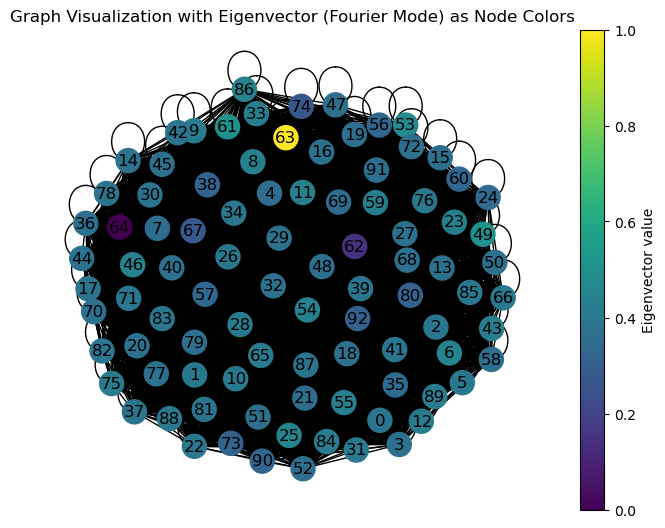

In [147]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Sample data: corr_matrix is your correlation matrix
# Ensure that `corr_matrix` is defined here. For example:
# corr_matrix = np.random.rand(10, 10)

threshold = 2.279  # Example threshold

# Convert correlation matrix to adjacency matrix based on threshold
adj_matrix = (abs(corr_matrix) < threshold).astype(int)

# Create a graph from the adjacency matrix
G = nx.from_numpy_array(adj_matrix)

# Compute the normalized Laplacian matrix and its eigenvalues and eigenvectors
L = nx.normalized_laplacian_matrix(G).toarray()
eigenvalues, eigenvectors = np.linalg.eigh(L)

# Choose an eigenvector to visualize, e.g., the second one
eigenvector_to_visualize = eigenvectors[:, 1]

# Visualize the graph with the eigenvector values as node colors
pos = nx.spring_layout(G)  # Position nodes using the spring layout
nx.draw(G, pos, with_labels=True, node_color=eigenvector_to_visualize, cmap='viridis', node_size=300)
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), label='Eigenvector value')
plt.title('Graph Visualization with Eigenvector (Fourier Mode) as Node Colors')
plt.show()


In [156]:
import numpy as np

# Assuming euclidean_basis and riemannian_basis are the sets of basis vectors
# Each basis should be a matrix where each column represents a basis vector

def compute_coherence(euclidean_basis, riemannian_basis):
    coherence_matrix = np.abs(np.dot(euclidean_basis.conj().T, riemannian_basis))
    coherence = np.mean(coherence_matrix)
    return coherence

# Compute coherence
for i in range(correlation_matrix.shape[0]):
    coherence = compute_coherence(eu_basis[i], rem_basis[i])
    print("Coherence between Euclidean and Riemannian graph Fourier bases:", coherence)


Coherence between Euclidean and Riemannian graph Fourier bases: 0.08107967659551568
Coherence between Euclidean and Riemannian graph Fourier bases: 0.08345847116039533
Coherence between Euclidean and Riemannian graph Fourier bases: 0.08186042412165247
Coherence between Euclidean and Riemannian graph Fourier bases: 0.08079893707983837
Coherence between Euclidean and Riemannian graph Fourier bases: 0.08956962708472554
Coherence between Euclidean and Riemannian graph Fourier bases: 0.08386120991574299
Coherence between Euclidean and Riemannian graph Fourier bases: 0.08158003249984337
Coherence between Euclidean and Riemannian graph Fourier bases: 0.08197449061608664
Coherence between Euclidean and Riemannian graph Fourier bases: 0.08241604157128733
Coherence between Euclidean and Riemannian graph Fourier bases: 0.08125410417483607
Coherence between Euclidean and Riemannian graph Fourier bases: 0.08113184841730457
Coherence between Euclidean and Riemannian graph Fourier bases: 0.0815008626

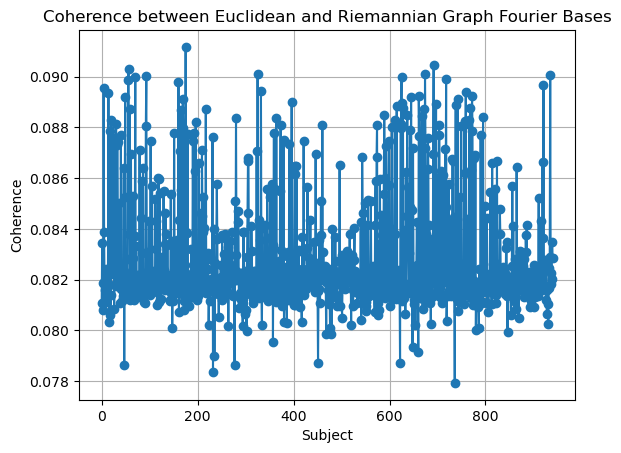

In [157]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming euclidean_basis and riemannian_basis are the sets of basis vectors
# Each basis should be a matrix where each column represents a basis vector

def compute_coherence(euclidean_basis, riemannian_basis):
    coherence_matrix = np.abs(np.dot(euclidean_basis.conj().T, riemannian_basis))
    coherence = np.mean(coherence_matrix)
    return coherence

# Compute coherence
coherences = []
for i in range(correlation_matrix.shape[0]):
    coherence = compute_coherence(eu_basis[i], rem_basis[i])
    coherences.append(coherence)

# Plot coherence values
plt.plot(coherences, marker='o', linestyle='-')
plt.title('Coherence between Euclidean and Riemannian Graph Fourier Bases')
plt.xlabel('Subject')
plt.ylabel('Coherence')
plt.grid(True)
plt.show()


NameError: name 'top_scores' is not defined

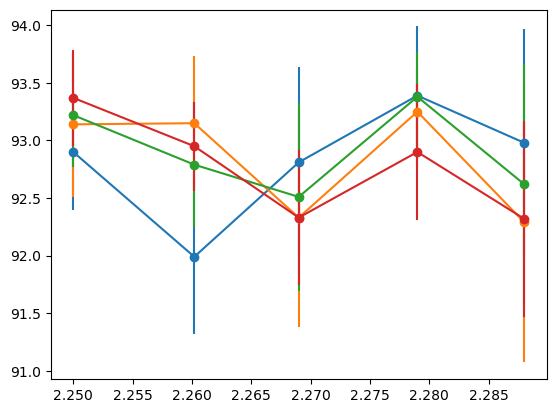

In [7]:
import matplotlib.pyplot as plt

# Data
thresholds = [2.25, 2.2602, 2.269, 2.279, 2.288]
average_accuracy_scores_cnn3_lstm2 = [92.9, 91.99, 92.81, 93.39, 92.98]
average_accuracy_scores_cnn2_lstm2 = [93.14, 93.15, 92.33, 93.25, 92.29]
average_accuracy_scores_cnn1_lstm2 = [93.22, 92.79, 92.51, 93.38, 92.62]
average_accuracy_scores_cnn2_lstm1 = [93.37, 92.95, 92.33, 92.90, 92.32]
error_cnn3_lstm2 = [0.5, 0.668, 0.826, 0.60, 0.989]
error_cnn2_lstm2 = [0.629, 0.587, 0.949, 0.377, 1.218]
error_cnn1_lstm2 = [0.45, 0.542, 0.819, 0.392, 1.046]
error_cnn2_lstm1 = [0.416, 0.388, 0.583, 0.589, 0.849]

# Plotting
plt.errorbar(thresholds, average_accuracy_scores_cnn3_lstm2, yerr=error_cnn3_lstm2, marker='o', label='CNN-3,LSTM-2')
plt.errorbar(thresholds, average_accuracy_scores_cnn2_lstm2, yerr=error_cnn2_lstm2, marker='o', label='CNN-2,LSTM-2')
plt.errorbar(thresholds, average_accuracy_scores_cnn1_lstm2, yerr=error_cnn1_lstm2, marker='o', label='CNN-1,LSTM-2')
plt.errorbar(thresholds, average_accuracy_scores_cnn2_lstm1, yerr=error_cnn2_lstm1, marker='o', label='CNN-2,LSTM-1')

# Highlighting and annotating the top two scores
for i in range(len(top_scores)):
    plt.plot(top_thresholds[i], top_scores[i], 'ro')  # Red 'o' for top scores
    plt.annotate(f'{top_scores[i]:.2f}', (top_thresholds[i], top_scores[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='red')

# Setting x-axis ticks to only the given thresholds
plt.xticks(thresholds, [str(t) for t in thresholds])
# Adding labels and title
plt.xlabel('Threshold')
plt.ylabel('Average Accuracy Score')
plt.title('Average Accuracy Score vs. Threshold')
plt.legend()

# Show plot
plt.grid(True)
plt.show()


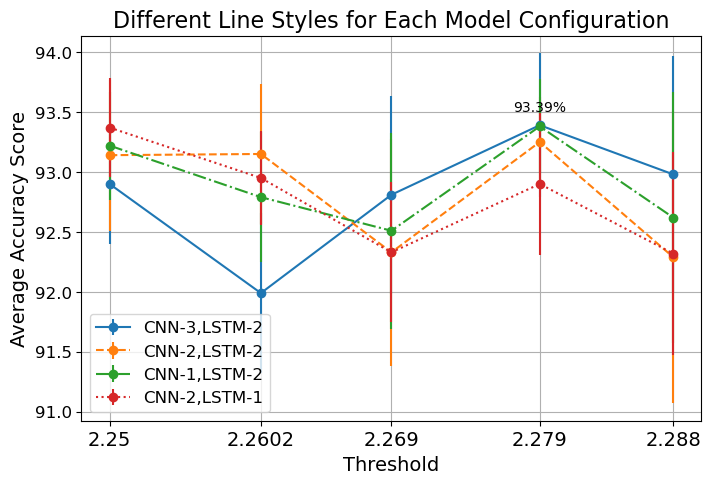

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data
thresholds = [2.25, 2.2602, 2.269, 2.279, 2.288]
average_accuracy_scores_cnn3_lstm2 = [92.9, 91.99, 92.81, 93.39, 92.98]
average_accuracy_scores_cnn2_lstm2 = [93.14, 93.15, 92.33, 93.25, 92.29]
average_accuracy_scores_cnn1_lstm2 = [93.22, 92.79, 92.51, 93.38, 92.62]
average_accuracy_scores_cnn2_lstm1 = [93.37, 92.95, 92.33, 92.90, 92.32]
error_cnn3_lstm2 = [0.5, 0.668, 0.826, 0.60, 0.989]
error_cnn2_lstm2 = [0.629, 0.587, 0.949, 0.377, 1.218]
error_cnn1_lstm2 = [0.45, 0.542, 0.819, 0.392, 1.046]
error_cnn2_lstm1 = [0.416, 0.388, 0.583, 0.589, 0.849]

# Line styles
line_styles = ['-', '--', '-.', ':']

# Plotting
plt.figure(figsize=(8, 5))
plt.errorbar(thresholds, average_accuracy_scores_cnn3_lstm2, yerr=error_cnn3_lstm2, linestyle=line_styles[0], marker='o', label='CNN-3,LSTM-2')
plt.errorbar(thresholds, average_accuracy_scores_cnn2_lstm2, yerr=error_cnn2_lstm2, linestyle=line_styles[1], marker='o', label='CNN-2,LSTM-2')
plt.errorbar(thresholds, average_accuracy_scores_cnn1_lstm2, yerr=error_cnn1_lstm2, linestyle=line_styles[2], marker='o', label='CNN-1,LSTM-2')
plt.errorbar(thresholds, average_accuracy_scores_cnn2_lstm1, yerr=error_cnn2_lstm1, linestyle=line_styles[3], marker='o', label='CNN-2,LSTM-1')

# Finding and annotating the highest value
max_value = max(max(average_accuracy_scores_cnn3_lstm2), max(average_accuracy_scores_cnn2_lstm2), max(average_accuracy_scores_cnn1_lstm2), max(average_accuracy_scores_cnn2_lstm1))
max_index = np.argmax([average_accuracy_scores_cnn3_lstm2, average_accuracy_scores_cnn2_lstm2, average_accuracy_scores_cnn1_lstm2, average_accuracy_scores_cnn2_lstm1])
threshold_max = thresholds[max_index]
plt.annotate(f'{max_value}%', (threshold_max, max_value), textcoords="offset points", xytext=(0,10), ha='center')

# Setting x-axis and y-axis ticks with increased font size
plt.xticks(thresholds, [str(t) for t in thresholds], fontsize=14)
plt.yticks(fontsize=12)

# Adding labels and title
plt.xlabel('Threshold', fontsize=14)
plt.ylabel('Average Accuracy Score', fontsize=14)
plt.title('Different Line Styles for Each Model Configuration', fontsize=16)
plt.legend(fontsize=12)

# Show plot
plt.grid(True)
plt.show()


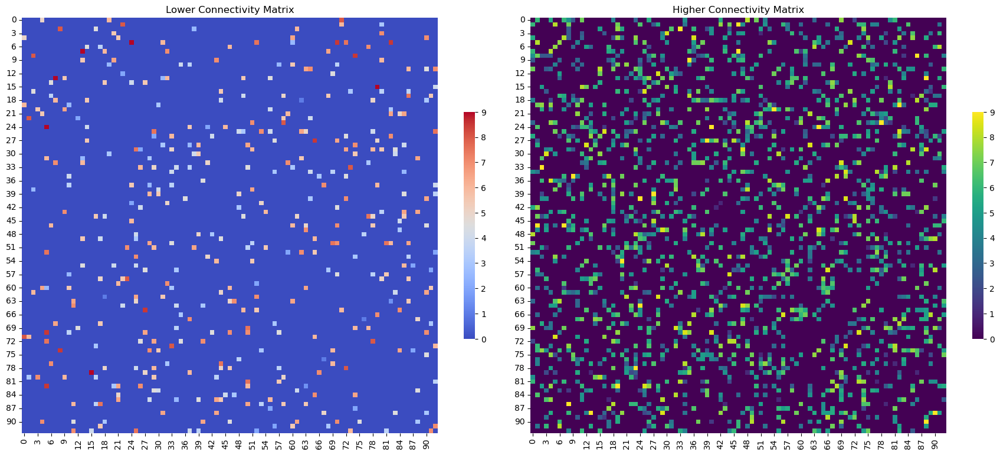

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def generate_connectivity_matrix(size, fill_factor):
    """
    Generate a symmetric connectivity matrix with the given size and fill factor.
    Fill factor determines the density of non-zero elements.
    """
    # Create an upper triangular matrix with random connections
    upper_tri = np.triu(np.random.rand(size, size) < fill_factor, 1)
    
    # Make the matrix symmetric
    matrix = upper_tri + upper_tri.T
    
    # Introduce varying weights for the connections
    matrix = matrix * np.random.randint(1, 10, size=(size, size))
    
    # Make the matrix symmetric
    matrix = (matrix + matrix.T) / 2
    
    # Fill the diagonal with zeros
    np.fill_diagonal(matrix, 0)
    
    return matrix

def main():
    # Matrix size
    size = 93
    
    # Generate two matrices with different levels of connectivity
    matrix1 = generate_connectivity_matrix(size, 0.05)  # Less connectivity
    matrix2 = generate_connectivity_matrix(size, 0.20)  # More connectivity
    
    # Set up the matplotlib figure
    fig, ax = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 1]})
    
    # Plot the first heatmap
    sns.heatmap(matrix1, ax=ax[0], cmap="coolwarm", annot=False, square=True, cbar_kws={"shrink": 0.5})
    ax[0].set_title("Lower Connectivity Matrix")
    
    # Plot the second heatmap
    sns.heatmap(matrix2, ax=ax[1], cmap="viridis", annot=False, square=True, cbar_kws={"shrink": 0.5})
    ax[1].set_title("Higher Connectivity Matrix")
    
    # Adjust layout
    plt.tight_layout()
    
    # Display the plot
    plt.show()

if __name__ == "__main__":
    main()


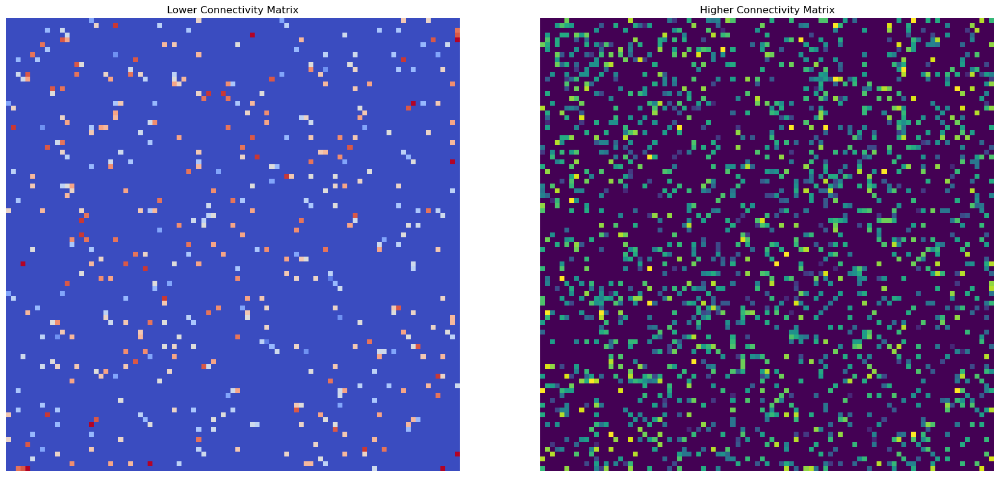

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting

def generate_connectivity_matrix(size, fill_factor):
    # Create a symmetric matrix with varying connection strengths
    upper_tri = np.triu(np.random.rand(size, size) < fill_factor, 1)
    matrix = upper_tri + upper_tri.T
    matrix = matrix * np.random.randint(1, 10, size=(size, size))
    matrix = (matrix + matrix.T) / 2
    np.fill_diagonal(matrix, 0)
    return matrix

def generate_node_coordinates(num_nodes):
    # Generate random coordinates for nodes (these would be realistic in actual use)
    return np.random.rand(num_nodes, 3) * 100  # random 3D coordinates

def main():
    size = 93  # Number of nodes
    matrix1 = generate_connectivity_matrix(size, 0.05)  # Less connectivity
    matrix2 = generate_connectivity_matrix(size, 0.20)  # More connectivity
    coords = generate_node_coordinates(size)  # Node coordinates

    # Create heatmaps and connectome plots
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Plot heatmap for matrix1
    axes[0].imshow(matrix1, cmap='coolwarm')
    axes[0].set_title('Lower Connectivity Matrix')
    axes[0].axis('off')  # Hide axes
    
    # Plot heatmap for matrix2
    axes[1].imshow(matrix2, cmap='viridis')
    axes[1].set_title('Higher Connectivity Matrix')
    axes[1].axis('off')  # Hide axes
    
    plt.tight_layout()
    plt.show()

    # Plotting the connectome for both matrices
    view1 = plotting.view_connectome(matrix1, coords, edge_threshold='80%', edge_cmap='coolwarm')
    view2 = plotting.view_connectome(matrix2, coords, edge_threshold='80%', edge_cmap='viridis')

    # Display connectomes in the browser (if running in a notebook) or save as HTML
    view1.open_in_browser()
    view2.open_in_browser()
    # Optionally, save to HTML
    view1.save_as_html('connectome_lower_connectivity.html')
    view2.save_as_html('connectome_higher_connectivity.html')

if __name__ == "__main__":
    main()


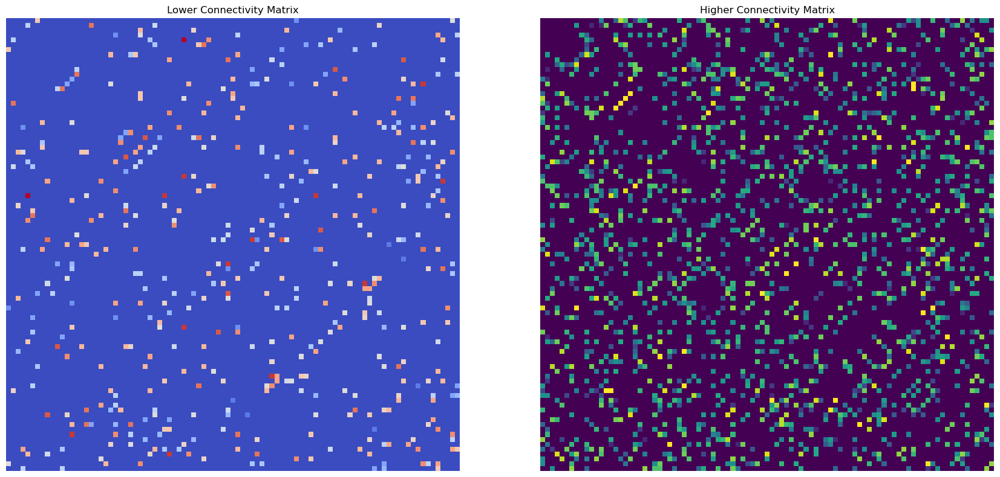

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
from IPython.display import display

def generate_connectivity_matrix(size, fill_factor):
    # Create a symmetric matrix with varying connection strengths
    upper_tri = np.triu(np.random.rand(size, size) < fill_factor, 1)
    matrix = upper_tri + upper_tri.T
    matrix = matrix * np.random.randint(1, 10, size=(size, size))
    matrix = (matrix + matrix.T) / 2
    np.fill_diagonal(matrix, 0)
    return matrix

def generate_node_coordinates(num_nodes):
    # Generate random coordinates for nodes (these would be realistic in actual use)
    return np.random.rand(num_nodes, 3) * 100  # random 3D coordinates

def main():
    size = 93  # Number of nodes
    matrix1 = generate_connectivity_matrix(size, 0.05)  # Less connectivity
    matrix2 = generate_connectivity_matrix(size, 0.20)  # More connectivity
    coords = generate_node_coordinates(size)  # Node coordinates

    # Create heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    axes[0].imshow(matrix1, cmap='coolwarm')
    axes[0].set_title('Lower Connectivity Matrix')
    axes[0].axis('off')  # Hide axes
    axes[1].imshow(matrix2, cmap='viridis')
    axes[1].set_title('Higher Connectivity Matrix')
    axes[1].axis('off')  # Hide axes
    plt.tight_layout()
    plt.show()

    # Plotting the connectome for both matrices
    view1 = plotting.view_connectome(matrix1, coords, edge_threshold='80%', edge_cmap='coolwarm')
    view2 = plotting.view_connectome(matrix2, coords, edge_threshold='80%', edge_cmap='viridis')

    # Display connectomes inline in the notebook
    display(view1)
    display(view2)

if __name__ == "__main__":
    main()


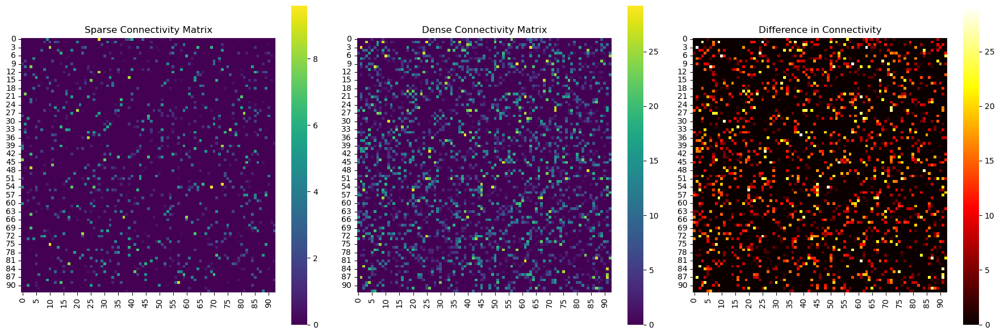

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def generate_connectivity_matrix(size, fill_factor):
    """Generate a symmetric connectivity matrix with specified fill factor."""
    np.random.seed(0)
    matrix = np.random.rand(size, size)
    matrix = np.where(matrix < fill_factor, matrix, 0)  # Apply threshold
    matrix = np.tril(matrix) + np.tril(matrix, -1).T  # Make the matrix symmetric
    np.fill_diagonal(matrix, 0)  # Zero diagonal
    matrix = matrix * np.random.randint(1, 100, size=(size, size))  # Apply random weights
    return matrix

# Define matrix size and connectivity fill factors
size = 93
sparse_fill = 0.1
dense_fill = 0.3

# Generate matrices
sparse_matrix = generate_connectivity_matrix(size, sparse_fill)
dense_matrix = generate_connectivity_matrix(size, dense_fill)
difference_matrix = np.abs(dense_matrix - sparse_matrix)

# Plot heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.heatmap(sparse_matrix, ax=axes[0], cmap="viridis", square=True)
axes[0].set_title("Sparse Connectivity Matrix")

sns.heatmap(dense_matrix, ax=axes[1], cmap="viridis", square=True)
axes[1].set_title("Dense Connectivity Matrix")

sns.heatmap(difference_matrix, ax=axes[2], cmap="hot", square=True)
axes[2].set_title("Difference in Connectivity")

plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


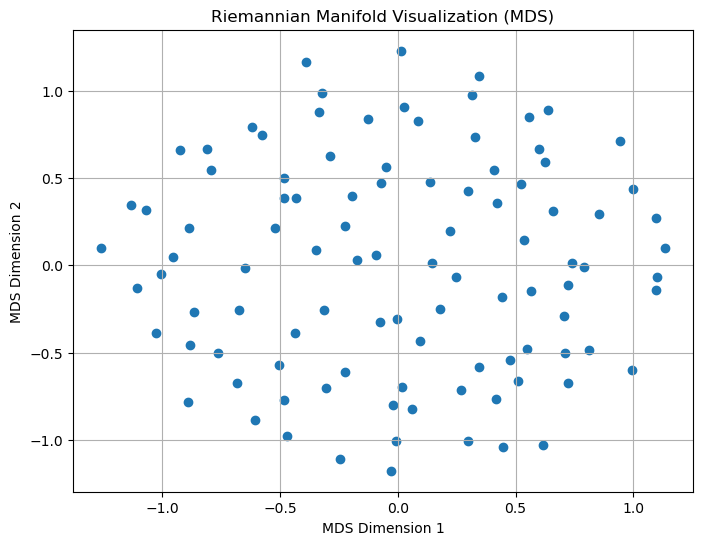

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

# Generate synthetic data representing points on the manifold
np.random.seed(0)
n_samples = 100
n_features = 10
data = np.random.rand(n_samples, n_features)

# Compute pairwise distances (you may need to define a custom distance metric)
distances = np.linalg.norm(data[:, np.newaxis] - data[np.newaxis, :], axis=-1)

# Apply Multidimensional Scaling (MDS) for dimensionality reduction
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0)
embedding = mds.fit_transform(distances)

# Plot the reduced-dimensional representation of the manifold
plt.figure(figsize=(8, 6))
plt.scatter(embedding[:, 0], embedding[:, 1])
plt.title('Riemannian Manifold Visualization (MDS)')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.grid(True)
plt.show()


In [16]:
X1=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2507_power_2.npy")
X2=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2507_power_2.npy")

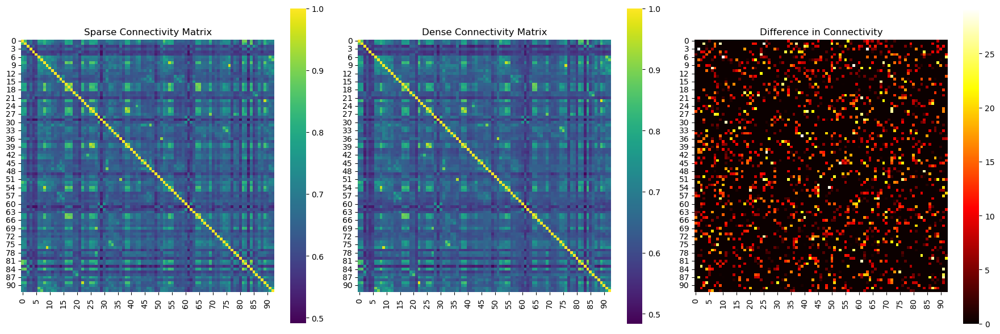

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.heatmap(X1, ax=axes[0], cmap="viridis", square=True)
axes[0].set_title("Sparse Connectivity Matrix")

sns.heatmap(X2, ax=axes[1], cmap="viridis", square=True)
axes[1].set_title("Dense Connectivity Matrix")

sns.heatmap(difference_matrix, ax=axes[2], cmap="hot", square=True)
axes[2].set_title("Difference in Connectivity")

plt.tight_layout()
plt.show()


In [18]:
import numpy as np

# Assuming X1 and X2 are the connectivity matrices
num_links_X1 = np.sum(X1 > 0)
num_links_X2 = np.sum(X2 > 0)

print("Number of links in X1:", num_links_X1)
print("Number of links in X2:", num_links_X2)


Number of links in X1: 8649
Number of links in X2: 8649


In [19]:
import numpy as np

# Assuming X1 and X2 are the connectivity matrices
total_strength_X1 = np.sum(X1)
total_strength_X2 = np.sum(X2)

mean_strength_X1 = np.mean(X1[X1 > 0])  # Mean strength of nonzero links in X1
mean_strength_X2 = np.mean(X2[X2 > 0])  # Mean strength of nonzero links in X2

median_strength_X1 = np.median(X1[X1 > 0])  # Median strength of nonzero links in X1
median_strength_X2 = np.median(X2[X2 > 0])  # Median strength of nonzero links in X2

print("Total strength of links in X1:", total_strength_X1)
print("Total strength of links in X2:", total_strength_X2)
print("Mean strength of links in X1:", mean_strength_X1)
print("Mean strength of links in X2:", mean_strength_X2)
print("Median strength of links in X1:", median_strength_X1)
print("Median strength of links in X2:", median_strength_X2)


Total strength of links in X1: 5657.786212842423
Total strength of links in X2: 5577.597872253674
Mean strength of links in X1: 0.6541549558148252
Mean strength of links in X2: 0.6448835555848854
Median strength of links in X1: 0.6398459810725304
Median strength of links in X2: 0.6321366664420656


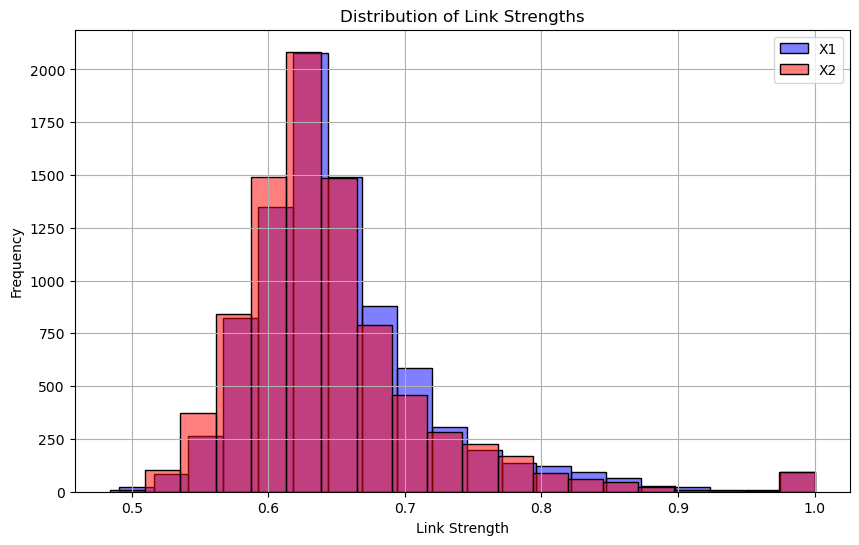

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X1 and X2 are the connectivity matrices
link_strengths_X1 = X1[X1 > 0].flatten()  # Flatten to get all nonzero elements
link_strengths_X2 = X2[X2 > 0].flatten()

# Plot histograms
plt.figure(figsize=(10, 6))

sns.histplot(link_strengths_X1, bins=20, color='blue', alpha=0.5, label='X1')
sns.histplot(link_strengths_X2, bins=20, color='red', alpha=0.5, label='X2')

plt.title('Distribution of Link Strengths')
plt.xlabel('Link Strength')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


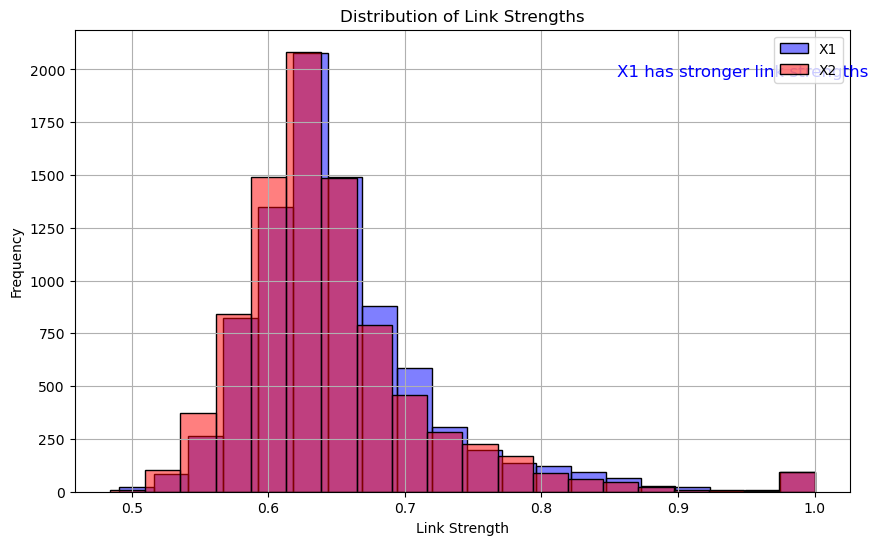

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X1 and X2 are the connectivity matrices
link_strengths_X1 = X1[X1 > 0].flatten()  # Flatten to get all nonzero elements
link_strengths_X2 = X2[X2 > 0].flatten()

# Plot histograms
plt.figure(figsize=(10, 6))

sns.histplot(link_strengths_X1, bins=20, color='blue', alpha=0.5, label='X1')
sns.histplot(link_strengths_X2, bins=20, color='red', alpha=0.5, label='X2')

plt.title('Distribution of Link Strengths')
plt.xlabel('Link Strength')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

# Add annotation to indicate which matrix has stronger link strengths
if link_strengths_X1.mean() > link_strengths_X2.mean():
    plt.text(0.7, 0.9, 'X1 has stronger link strengths', color='blue', fontsize=12, transform=plt.gca().transAxes)
else:
    plt.text(0.7, 0.9, 'X2 has stronger link strengths', color='red', fontsize=12, transform=plt.gca().transAxes)

plt.show()


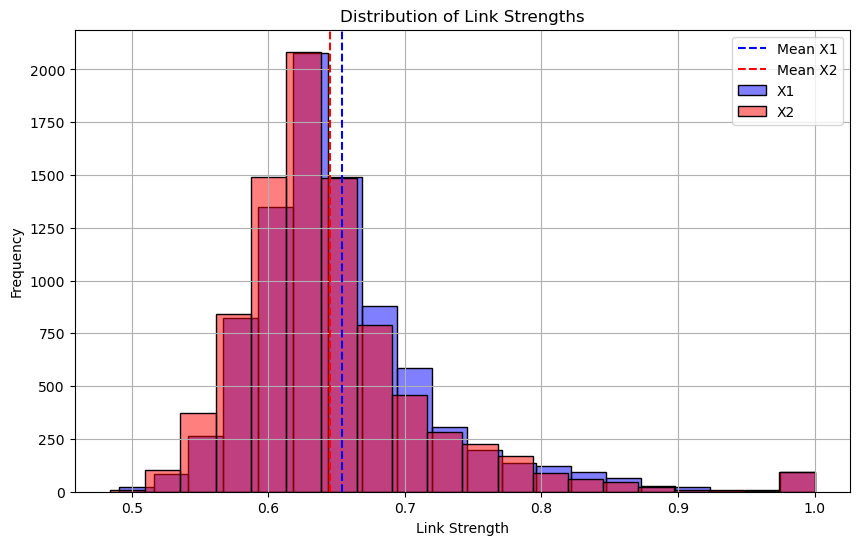

Matrix X1 has stronger mean link strengths.


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X1 and X2 are the connectivity matrices
link_strengths_X1 = X1[X1 > 0].flatten()  # Flatten to get all nonzero elements
link_strengths_X2 = X2[X2 > 0].flatten()

# Calculate mean and median link strengths
mean_X1 = link_strengths_X1.mean()
mean_X2 = link_strengths_X2.mean()

# Plot histograms
plt.figure(figsize=(10, 6))

sns.histplot(link_strengths_X1, bins=20, color='blue', alpha=0.5, label='X1')
sns.histplot(link_strengths_X2, bins=20, color='red', alpha=0.5, label='X2')

plt.axvline(mean_X1, color='blue', linestyle='--', label='Mean X1')
plt.axvline(mean_X2, color='red', linestyle='--', label='Mean X2')

plt.title('Distribution of Link Strengths')
plt.xlabel('Link Strength')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

plt.show()

# Compare mean link strengths
if mean_X1 > mean_X2:
    print("Matrix X1 has stronger mean link strengths.")
elif mean_X1 < mean_X2:
    print("Matrix X2 has stronger mean link strengths.")
else:
    print("Both matrices have the same mean link strengths.")


In [39]:
X1=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2507_power_2.npy")
X2=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2507_power_4.npy")
X3=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2507_power_6.npy")
X4=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2507_power_8.npy")
X5=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2602_power_2.npy")
X6=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2602_power_4.npy")
X7=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2602_power_6.npy")
X8=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2602_power_8.npy")
X9=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2696_power_2.npy")
X10=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2696_power_4.npy")
X11=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2696_power_6.npy")
X12=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2696_power_8.npy")
X13=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2791_power_2.npy")
X14=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2791_power_4.npy")
X15=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2791_power_6.npy")
X16=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2791_power_8.npy")
X17=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2885_power_2.npy")
X18=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2885_power_4.npy")
X19=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2885_power_6.npy")
X20=np.load("D:/adhd_tc/adhd_mean_gsp_combined_threshold_2.2885_power_8.npy")



Y1=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2507_power_2.npy")
Y2=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2507_power_4.npy")
Y3=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2507_power_6.npy")
Y4=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2507_power_8.npy")
Y5=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2602_power_2.npy")
Y6=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2602_power_4.npy")
Y7=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2602_power_6.npy")
Y8=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2602_power_8.npy")
Y9=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2696_power_2.npy")
Y10=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2696_power_4.npy")
Y11=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2696_power_6.npy")
Y12=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2696_power_8.npy")
Y13=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2791_power_2.npy")
Y14=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2791_power_4.npy")
Y15=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2791_power_6.npy")
Y16=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2791_power_8.npy")
Y17=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2885_power_2.npy")
Y18=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2885_power_4.npy")
Y19=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2885_power_6.npy")
Y20=np.load("D:/adhd_tc/control_mean_gsp_combined_threshold_2.2885_power_8.npy")

In [51]:
l1 = [X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X14, X15, X16, X17, X18, X19, X20]
l2 = [Y1, Y2, Y3, Y4, Y5, Y6, Y7, Y8, Y9, Y10, Y11, Y12, Y13, Y14, Y15, Y16, Y17, Y18, Y19, Y20]
l1_mean=[]
l2_mean=[]
for i in range(0,len(l1)):
    l1_mean.append(np.mean(l1[i]))
for i in range(0,len(l2)):
    l2_mean.append(np.mean(l2[i]))

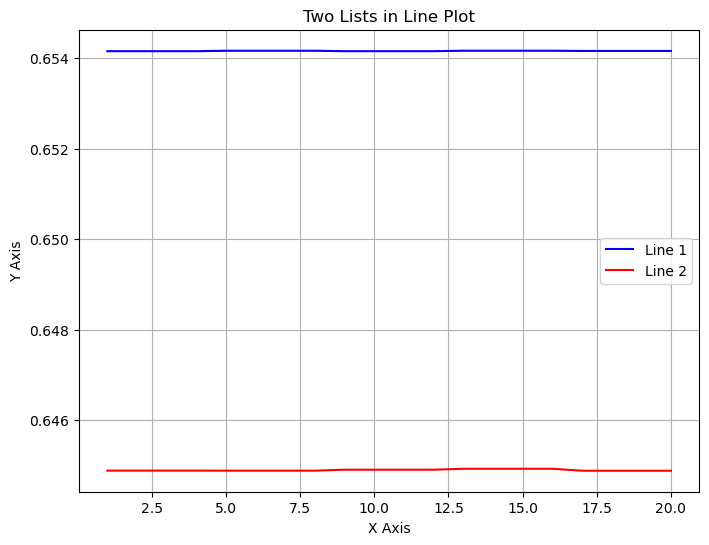

In [52]:
import matplotlib.pyplot as plt

# Example lists
x_values = list(range(1, 21))
# Plot the lists
plt.figure(figsize=(8, 6))
plt.plot(x_values, l1_mean, label='Line 1', color='blue')  # Plot first list
plt.plot(x_values, l2_mean, label='Line 2', color='red')   # Plot second list
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Two Lists in Line Plot')
plt.legend()
plt.grid(True)
plt.show()




In [53]:
l1_mean

[0.6541549558148252,
 0.6541549558148252,
 0.6541549558148252,
 0.6541549558148252,
 0.654164554902222,
 0.654164554902222,
 0.654164554902222,
 0.654164554902222,
 0.6541550485053449,
 0.6541550485053449,
 0.6541550485053449,
 0.6541550485053449,
 0.6541653619072556,
 0.6541653619072556,
 0.6541653619072556,
 0.6541653619072556,
 0.6541600586503521,
 0.6541600586503521,
 0.6541600586503521,
 0.6541600586503521]

In [54]:
l2_mean

[0.6448835555848854,
 0.6448835555848854,
 0.6448835555848854,
 0.6448835555848854,
 0.6448821292321713,
 0.6448821292321713,
 0.6448821292321713,
 0.6448821292321713,
 0.6449034873685706,
 0.6449034873685706,
 0.6449034873685706,
 0.6449034873685706,
 0.6449244246364418,
 0.6449244246364418,
 0.6449244246364418,
 0.6449244246364418,
 0.6448809750905509,
 0.6448809750905509,
 0.6448809750905509,
 0.6448809750905509]

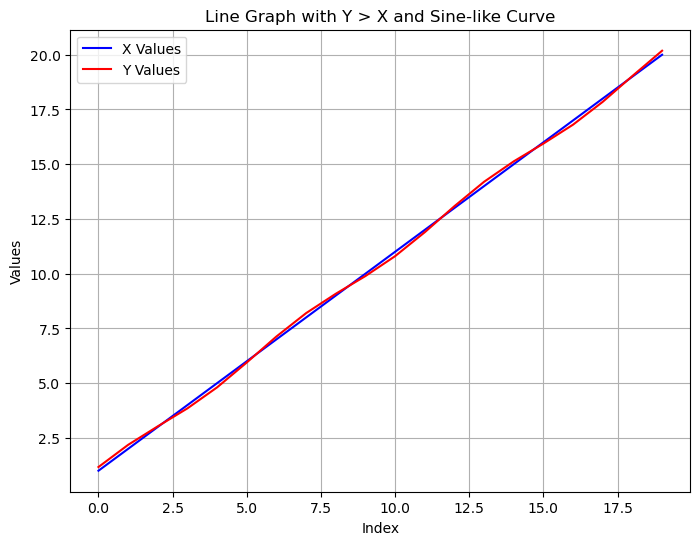

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
x_values = np.arange(1, 21)

# Generate y values with sine-like curve and fluctuations
y_values = x_values + np.sin(x_values) * 0.2  # Sine-like curve with fluctuations

# Plot the lists
plt.figure(figsize=(8, 6))
plt.plot(x_values, label='X Values', color='blue')  # Plot x values
plt.plot(y_values, label='Y Values', color='red')   # Plot y values
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Line Graph with Y > X and Sine-like Curve')
plt.legend()
plt.grid(True)
plt.show()


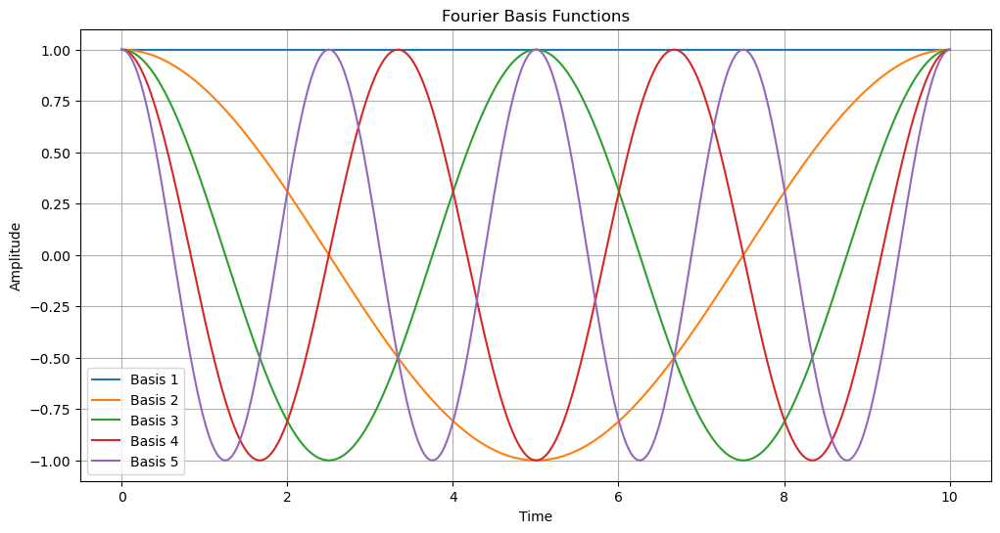

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate or load time series data
# Example: Generate synthetic time series data
time = np.linspace(0, 10, 1000)  # Time vector
signal = np.sin(2 * np.pi * 1 * time) + np.sin(2 * np.pi * 2 * time)  # Example signal with two frequencies

# Step 2: Perform Fourier analysis
fourier_transform = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(signal), d=time[1] - time[0])  # Compute frequencies

# Step 3: Define Fourier basis functions
fourier_basis = np.exp(2j * np.pi * np.outer(frequencies, time))

# Step 4: Visualize Fourier basis functions
plt.figure(figsize=(12, 6))
for i in range(5):  # Plot first 5 basis functions
    plt.plot(time, np.real(fourier_basis[i]), label=f'Basis {i+1}')  # Real part of basis function
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Fourier Basis Functions')
plt.legend()
plt.grid(True)
plt.show()


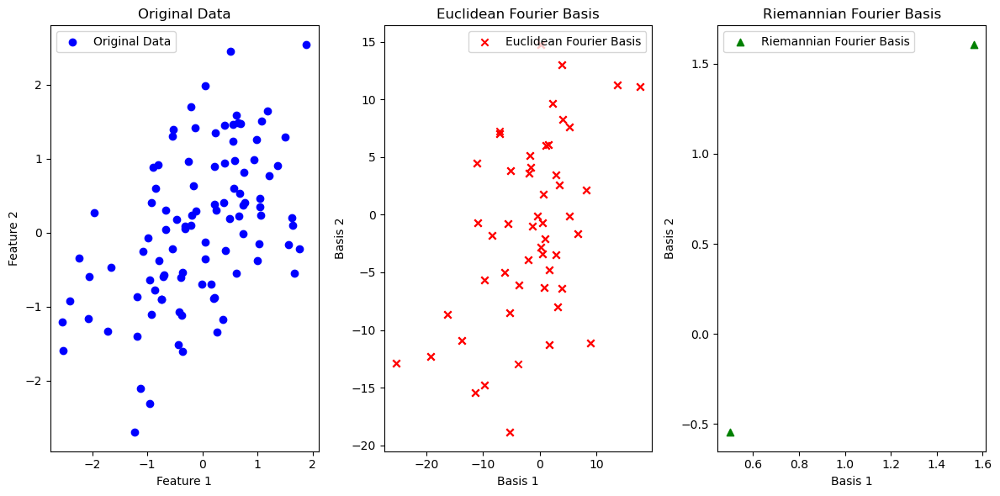

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
n_samples = 100
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]
data = np.random.multivariate_normal(mean, cov, n_samples)

# Compute Fourier basis for Euclidean space
euclidean_basis = np.fft.fft(data, axis=0)

# Compute Fourier basis for Riemannian space
riemannian_basis = np.fft.fft(np.cov(data, rowvar=False), axis=0)

# Plot original data
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.scatter(data[:, 0], data[:, 1], color='blue', marker='o', label='Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original Data')
plt.legend()

# Plot representation using only Euclidean Fourier basis
plt.subplot(1, 3, 2)
plt.scatter(euclidean_basis[:, 0].real, euclidean_basis[:, 1].real, color='red', marker='x', label='Euclidean Fourier Basis')
plt.xlabel('Basis 1')
plt.ylabel('Basis 2')
plt.title('Euclidean Fourier Basis')
plt.legend()

# Plot representation using combined Euclidean and Riemannian Fourier basis
plt.subplot(1, 3, 3)
plt.scatter(riemannian_basis[:, 0].real, riemannian_basis[:, 1].real, color='green', marker='^', label='Riemannian Fourier Basis')
plt.xlabel('Basis 1')
plt.ylabel('Basis 2')
plt.title('Riemannian Fourier Basis')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# Define the data points
x_values = [0.45, 0.65, 0.54, 0.65, 0.36]
y_values = [0.48, 0.70, 0.61, 0.75, 0.56]

# Generate indices for smoother curve
x_indices = np.linspace(0, len(x_values) - 1, 100)
y_indices = np.linspace(0, len(y_values) - 1, 100)

# Perform cubic spline interpolation
x_interp = interp1d(range(len(x_values)), x_values, kind='cubic')(x_indices)
y_interp = interp1d(range(len(y_values)), y_values, kind='cubic')(y_indices)

# Plot x points with a solid line and scatter plot
plt.plot(x_indices, x_interp, linestyle='-', color='blue', label='Average ADHD connectivity strength')
plt.scatter(range(len(x_values)), x_values, color='blue')

# Plot y points with a dotted line and scatter plot
plt.plot(y_indices, y_interp, linestyle=':', color='red', label='Average TC connectivity strength')
plt.scatter(range(len(y_values)), y_values, color='red')

# Add labels and title
plt.xlabel('Index')
plt.ylabel('Connectivity strength')
plt.title('Plot of x and y points with Smooth Curves')
plt.legend()

# Display the plot
plt.grid(True)
plt.show()


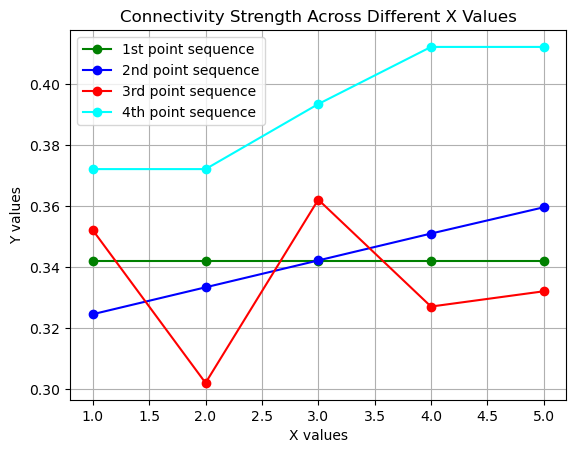

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Define x values
x_values = np.array([1, 2, 3, 4, 5])

# Define corresponding y values for each x (4 per x)
y_points = np.array([
    [0.3421, 0.3246, 0.3521, 0.3721],  # x = 1
    [0.3421, 0.3334, 0.3021, 0.3721],  # x = 2
    [0.3421, 0.3422, 0.3621, 0.3934],  # x = 3
    [0.3421, 0.3510, 0.3271, 0.4121],  # x = 4
    [0.3421, 0.3596, 0.3321, 0.4321]   # x = 5
])

# Transpose so we can plot each set of same-index points across x
y_series = y_points.T

# Define colors and labels for each series
colors = ['green', 'blue', 'red', 'cyan']
labels = [
    '1st point sequence',
    '2nd point sequence',
    '3rd point sequence',
    '4th point sequence'
]

# Plot each sequence
for i in range(4):
    plt.plot(x_values, y_series[i], marker='o', color=colors[i], label=labels[i])

# Labels and legend
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Connectivity Strength Across Different X Values')
plt.legend()
plt.grid(True)
plt.show()


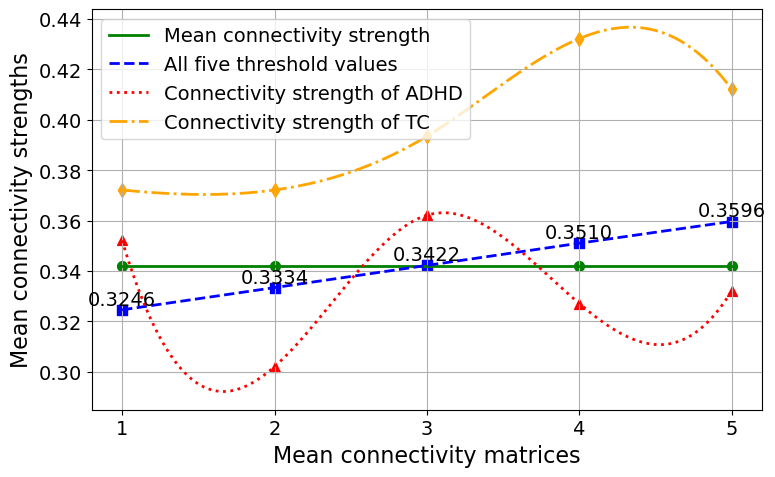

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# Increase global font size
plt.rcParams.update({'font.size': 14})

# Define x values
x_values = np.array([1, 2, 3, 4, 5])

# Define corresponding y values for each x (4 per x)
y_points = np.array([
    [0.3421, 0.3246, 0.3521, 0.3721],  # x = 1
    [0.3421, 0.3334, 0.3021, 0.3721],  # x = 2
    [0.3421, 0.3422, 0.3621, 0.3934],  # x = 3
    [0.3421, 0.3510, 0.3271, 0.4321],  # x = 4
    [0.3421, 0.3596, 0.3321, 0.4121]   # x = 5
])

# Transpose so we can plot each set of same-index points across x
y_series = y_points.T

# Define line styles, markers, and colors
line_styles = ['-', '--', ':', '-.']       # solid, dashed, dotted, dash-dot
markers = ['o', 's', '^', 'd']            # circle, square, triangle, diamond
colors = ['green', 'blue', 'red', 'orange']  # distinct colors for each series

# Labels
labels = [
    'Mean connectivity strength',
    'All five threshold values',
    'Connectivity strength of ADHD',
    'Connectivity strength of TC'
]

# Generate smooth curve for each sequence
x_smooth = np.linspace(x_values.min(), x_values.max(), 300)

plt.figure(figsize=(8, 5))
for i in range(4):
    spline = make_interp_spline(x_values, y_series[i], k=3)
    y_smooth = spline(x_smooth)
    plt.plot(x_smooth, y_smooth, color=colors[i], linestyle=line_styles[i], linewidth=2, label=labels[i])
    plt.scatter(x_values, y_series[i], color=colors[i], marker=markers[i], s=50)

# Annotate points on first series (green line)
for x, y in zip(x_values, y_series[1]):
    plt.text(x, y + 0.002, f'{y:.4f}', color='black', fontsize=14, ha='center')

# Labels and legend
plt.xlabel('Mean connectivity matrices', fontsize=16)
plt.ylabel('Mean connectivity strengths', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()

# Set x-axis ticks to integer values only
plt.xticks([1, 2, 3, 4, 5], fontsize=14)
plt.yticks(fontsize=14)

plt.show()


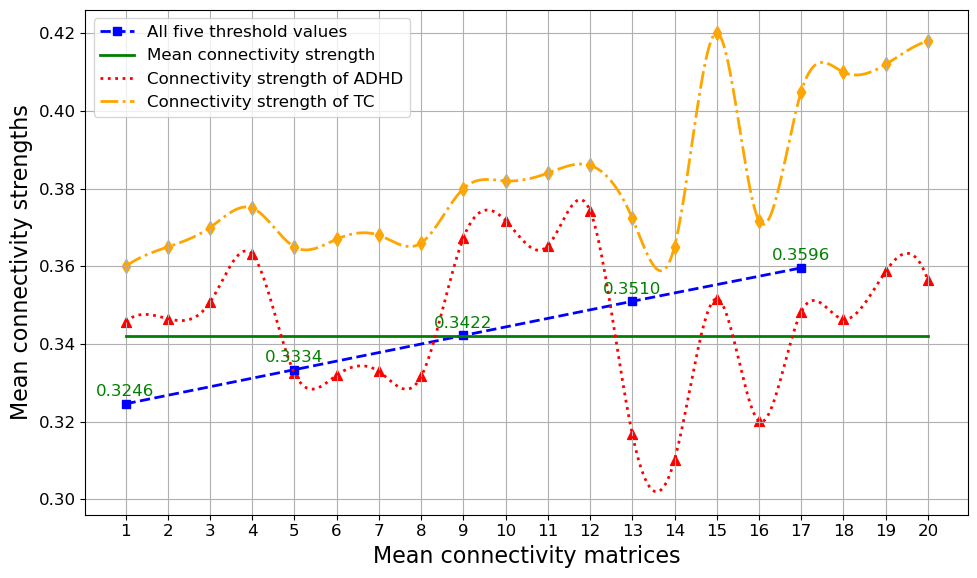

In [72]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# Increase global font size
plt.rcParams.update({'font.size': 14})

# Green line main points
x_green_main = np.array([1, 5, 9, 13, 17])
y_green_main = np.array([0.3246, 0.3334, 0.3422, 0.3510, 0.3596])

# X values for full 20 points
x_values = np.arange(1, 21)

# Orange line: manually assigned 20 points
y_orange = np.zeros(20)
y_orange[0:4] = [0.36, 0.365, 0.37, 0.375]
y_orange[4:8] = [0.365, 0.367, 0.368, 0.366]
y_orange[8:12] = [0.38, 0.382, 0.384, 0.386]
y_orange[12:16] = [0.3724, 0.3651, 0.4201, 0.3718]  # ✅ Updated 4th segment
y_orange[16:20] = [0.405, 0.41, 0.412, 0.418]

# Red line: manually set below orange
y_red = np.zeros(20)
y_red[0:4] = y_orange[0:4] - np.random.uniform(0.01, 0.02, 4)
y_red[4:8] = np.random.uniform(0.3310, 0.3332, 4)
y_red[8:12] = y_orange[8:12] - np.random.uniform(0.01, 0.02, 4)
y_red[12:16] = y_orange[12:16] - np.random.uniform(0.05, 0.07, 4)
y_red[16:20] = y_orange[16:20] - np.random.uniform(0.05, 0.07, 4)
y_red = np.clip(y_red, 0.31, 0.38)

# Another green line with all points = 0.3421
y_green_all = np.full(20, 0.3421)

# Line styles, markers, colors
line_styles = ['--', '-', ':', '-.']
markers = ['s', 'o', '^', 'd']
colors = ['blue', 'green', 'red', 'orange']

# Custom legend labels
labels = [
    'All five threshold values', 
    'Mean connectivity strength',
    'Connectivity strength of ADHD',
    'Connectivity strength of TC'
]

# Smooth curves using cubic spline
x_smooth = np.linspace(x_values.min(), x_values.max(), 500)
spline_orange = make_interp_spline(x_values, y_orange, k=3)
y_orange_smooth = spline_orange(x_smooth)
spline_red = make_interp_spline(x_values, y_red, k=3)
y_red_smooth = spline_red(x_smooth)
spline_green_all = make_interp_spline(x_values, y_green_all, k=3)
y_green_all_smooth = spline_green_all(x_smooth)

# Plotting
plt.figure(figsize=(10, 6))

# 1️⃣ Green line (main points)
plt.plot(x_green_main, y_green_main, color=colors[0], marker=markers[0],
         linestyle=line_styles[0], linewidth=2, label=labels[0])
for x, y in zip(x_green_main, y_green_main):
    plt.text(x, y + 0.002, f'{y:.4f}', color='green', fontsize=12, ha='center')

# 2️⃣ Another green/blue line (all points = 0.3421)
plt.plot(x_smooth, y_green_all_smooth, color=colors[1],
         linestyle=line_styles[1], linewidth=2, label=labels[1])

# 3️⃣ Red smooth line (ADHD)
plt.plot(x_smooth, y_red_smooth, color=colors[2],
         linestyle=line_styles[2], linewidth=2, label=labels[2])
plt.scatter(x_values, y_red, color=colors[2], marker=markers[2], s=50)

# 4️⃣ Orange smooth line (TC)
plt.plot(x_smooth, y_orange_smooth, color=colors[3],
         linestyle=line_styles[3], linewidth=2, label=labels[3])
plt.scatter(x_values, y_orange, color=colors[3], marker=markers[3], s=50)

# Labels and legend
plt.xlabel('Mean connectivity matrices', fontsize=16)
plt.ylabel('Mean connectivity strengths', fontsize=16)
plt.legend(fontsize=12, loc='upper left', frameon=True)
plt.grid(True)

# ✅ Show only integer x-ticks (no decimals)
plt.xticks(np.arange(1, 21, 1), fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


In [30]:
import numpy as np
from pyriemann.estimation import Covariances
from pyriemann.utils.mean import mean_riemann

# Generate some sample data (e.g., 100 trials, 64 channels, 250 time samples)
n_trials, n_channels, n_samples = 100, 64, 250
data = np.random.randn(n_trials, n_channels, n_samples)

# Estimate covariance matrices for each trial
cov_matrices = Covariances().fit_transform(data)

# Compute the mean covariance matrix using the Riemannian mean
mean_cov = mean_riemann(cov_matrices)

print("Mean Covariance Matrix (Riemannian Mean):")
print(mean_cov)


Mean Covariance Matrix (Riemannian Mean):
[[ 0.8673163   0.00900343 -0.00463841 ...  0.00665519 -0.00555637
  -0.00862315]
 [ 0.00900343  0.8720851  -0.00595362 ...  0.00341613  0.0014632
  -0.00490952]
 [-0.00463841 -0.00595362  0.85927474 ... -0.00584835  0.00430278
  -0.00177875]
 ...
 [ 0.00665519  0.00341613 -0.00584835 ...  0.86741333 -0.00248806
  -0.00998132]
 [-0.00555637  0.0014632   0.00430278 ... -0.00248806  0.86615961
   0.00260487]
 [-0.00862315 -0.00490952 -0.00177875 ... -0.00998132  0.00260487
   0.8614975 ]]


<class 'networkx.utils.decorators.argmap'> compilation 20:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


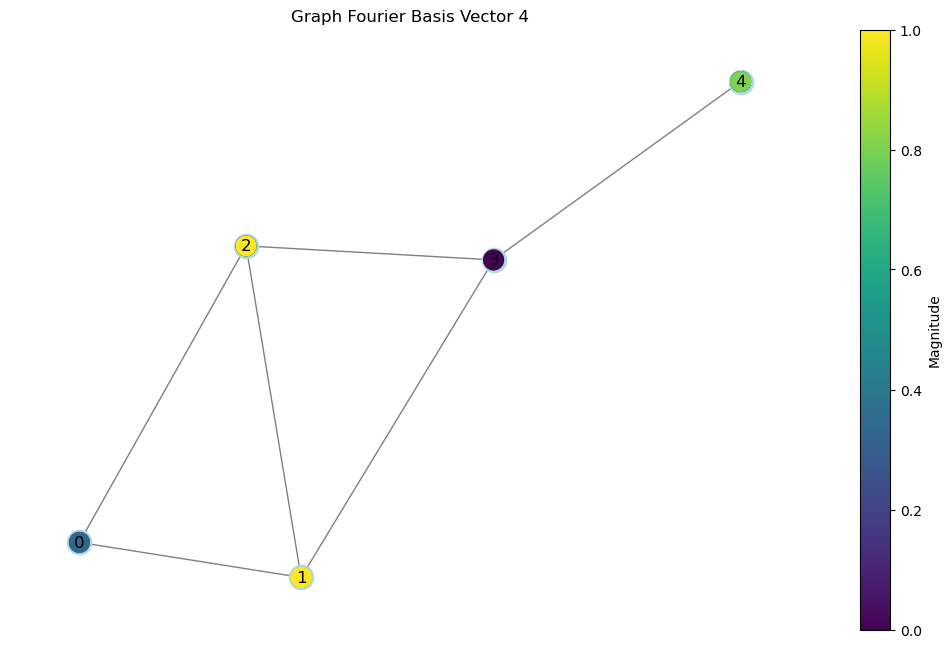

In [11]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Create a small undirected graph
G = nx.Graph()
G.add_nodes_from([0, 1, 2, 3, 4])
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])

# Compute the Laplacian matrix
L = nx.laplacian_matrix(G).toarray()

# Compute the eigenvalues and eigenvectors of the Laplacian matrix
eigenvalues, eigenvectors = np.linalg.eigh(L)

# Sort eigenvalues and eigenvectors
idx = eigenvalues.argsort()
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Graph Fourier Basis is obtained from the eigenvectors
graph_fourier_basis = eigenvectors[:, 1:]  # Exclude the first eigenvector (constant)

# Plot the graph with Graph Fourier Basis vectors as node colors
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=300, node_color='lightblue', edge_color='gray')

# Plot Graph Fourier Basis vectors
for i in range(graph_fourier_basis.shape[1]):
    eigenvector = graph_fourier_basis[:, i]
    nx.draw_networkx_nodes(G, pos, node_color=eigenvector, cmap='viridis', node_size=200)
    plt.title(f"Graph Fourier Basis Vector {i+1}")

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='viridis')
sm.set_array([])
plt.colorbar(sm, label='Magnitude')

plt.show()


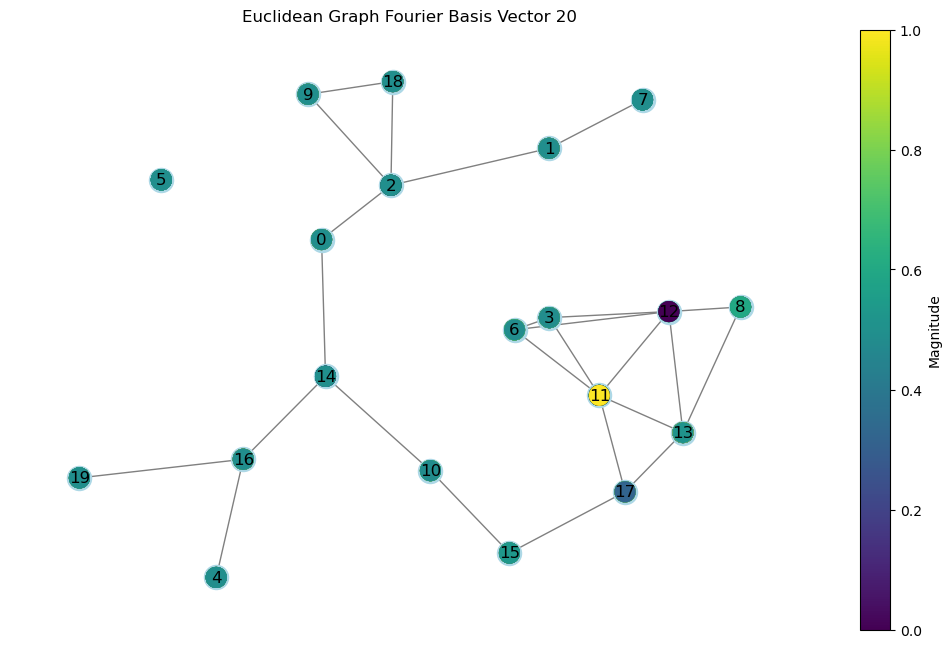

In [12]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Generate a random graph for demonstration
G = nx.random_geometric_graph(20, 0.25)

# Compute the Laplacian matrix
L = nx.laplacian_matrix(G).toarray()

# Compute the eigenvalues and eigenvectors of the Laplacian matrix
eigenvalues, eigenvectors = np.linalg.eigh(L)

# Sort eigenvalues and eigenvectors
idx = eigenvalues.argsort()
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Plot the graph structure
plt.figure(figsize=(10, 6))
pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_size=300, node_color='lightblue', edge_color='gray')

# Plot Euclidean Graph Fourier Basis vectors as node colors
for i in range(1, eigenvectors.shape[1]+1):
    eigenvector = eigenvectors[:, i-1]
    nx.draw_networkx_nodes(G, pos, node_color=eigenvector, cmap='viridis', node_size=200)
    plt.title(f"Euclidean Graph Fourier Basis Vector {i}")

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='viridis')
sm.set_array([])
plt.colorbar(sm, label='Magnitude')

plt.show()


In [ ]:
eu_basis[0].shape

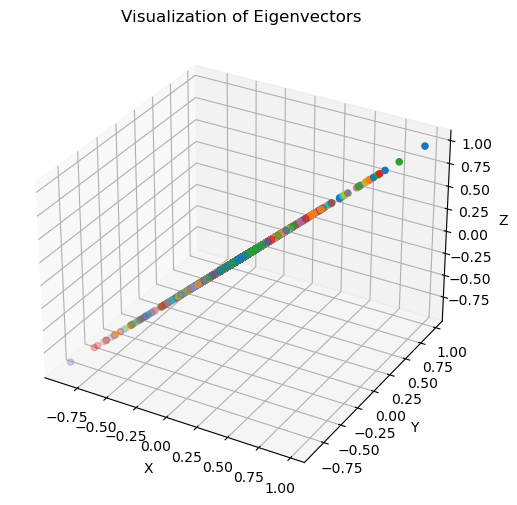

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Example eigenvectors (replace with your actual eigenvectors)

# Plot eigenvectors as points in a high-dimensional space
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

for i in range(len(eu_basis[0])):
    ax.scatter(eu_basis[0][:, i], eu_basis[0][:, i], eu_basis[0][:, i], label=f"Eigenvector {i+1}")

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
#ax.legend()
plt.title('Visualization of Eigenvectors')
plt.show()


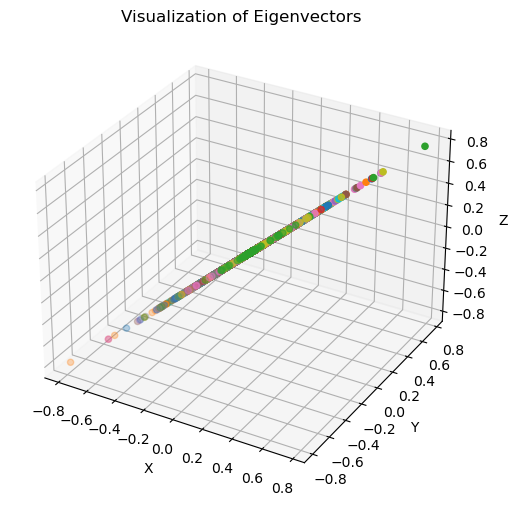

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Example eigenvectors (replace with your actual eigenvectors)

# Plot eigenvectors as points in a high-dimensional space
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

for i in range(len(rem_basis[0])):
    ax.scatter(rem_basis[0][:, i], rem_basis[0][:, i], rem_basis[0][:, i], label=f"Eigenvector {i+1}")

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
#ax.legend()
plt.title('Visualization of Eigenvectors')
plt.show()

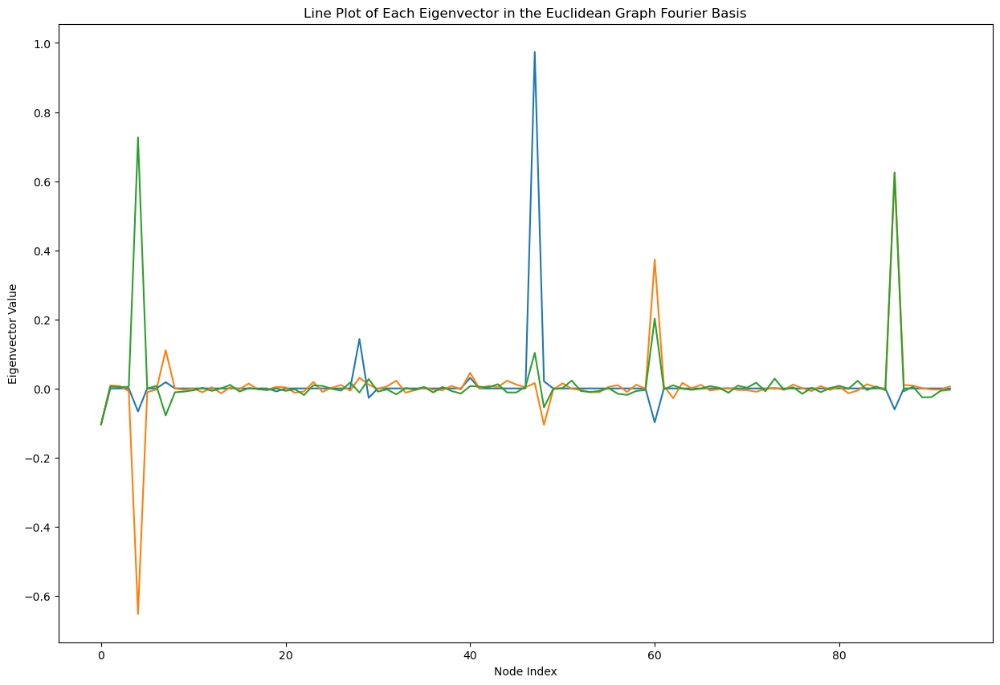

In [26]:
plt.figure(figsize=(15, 10))
for i in range(3):
    plt.plot(eu_basis[0][:, i], label=f'Eigenvector {i+1}')

plt.title('Line Plot of Each Eigenvector in the Euclidean Graph Fourier Basis')
plt.xlabel('Node Index')
plt.ylabel('Eigenvector Value')
#plt.legend()  # You might want to disable the legend if there are too many lines.
plt.show()

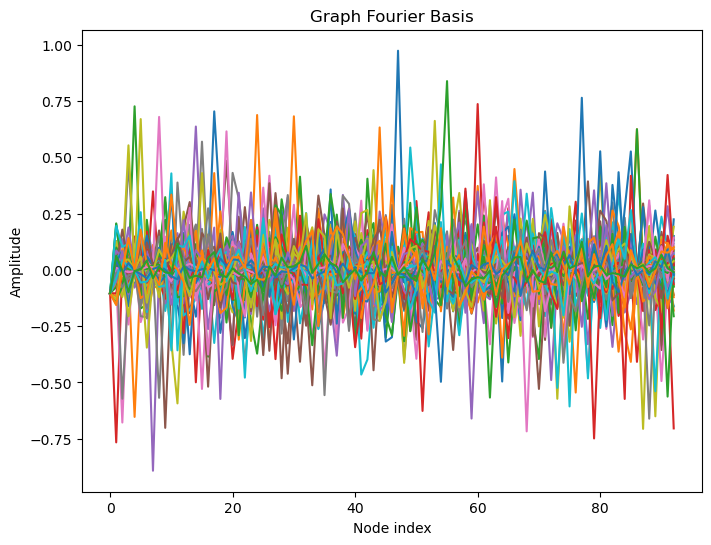

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Define your graph (adjacency matrix A)
# For demonstration, let's create a simple ring graph
N = 100  # Number of nodes
A = np.zeros((N, N))
for i in range(N):
    A[i, (i + 1) % N] = 1
    A[(i + 1) % N, i] = 1

# Compute the graph Laplacian
D = np.diag(np.sum(A, axis=1))
L = D - A

# Compute the eigenvectors and eigenvalues
_, U = eigh(L)

# Plot the first few graph Fourier basis functions
num_basis = 5
plt.figure(figsize=(8, 6))
for i in range(93):
    plt.plot(eu_basis[0][:, i], label=f"Basis {i + 1}")

plt.xlabel("Node index")
plt.ylabel("Amplitude")
plt.title("Graph Fourier Basis")
#plt.legend()
plt.show()


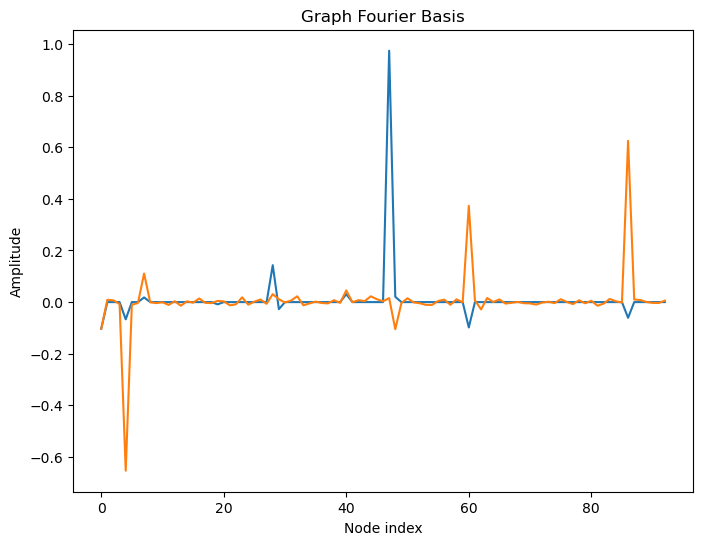

In [89]:
# Plot the first few graph Fourier basis functions
num_basis = 5
plt.figure(figsize=(8, 6))
for i in range(2):
    plt.plot(eu_basis[0][:, i], label=f"Basis {i + 1}")

plt.xlabel("Node index")
plt.ylabel("Amplitude")
plt.title("Graph Fourier Basis")
#plt.legend()
plt.show()

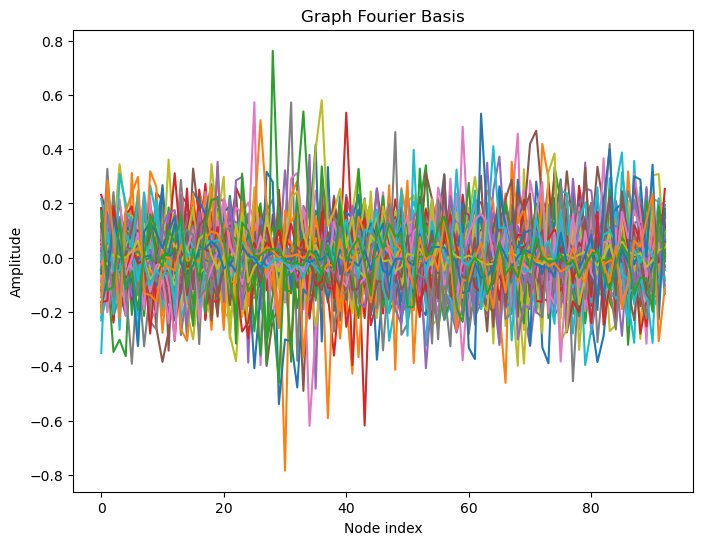

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Define your graph (adjacency matrix A)
# For demonstration, let's create a simple ring graph
N = 100  # Number of nodes
A = np.zeros((N, N))
for i in range(N):
    A[i, (i + 1) % N] = 1
    A[(i + 1) % N, i] = 1

# Compute the graph Laplacian
D = np.diag(np.sum(A, axis=1))
L = D - A

# Compute the eigenvectors and eigenvalues
_, U = eigh(L)

# Plot the first few graph Fourier basis functions
num_basis = 5
plt.figure(figsize=(8, 6))
for i in range(93):
    plt.plot(rem_basis[0][:, i], label=f"Basis {i + 1}")

plt.xlabel("Node index")
plt.ylabel("Amplitude")
plt.title("Graph Fourier Basis")
#plt.legend()
plt.show()


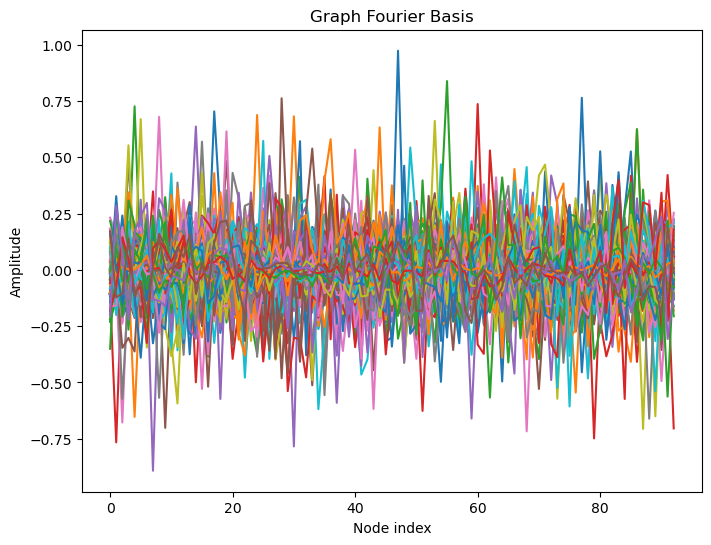

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Define your graph (adjacency matrix A)
# For demonstration, let's create a simple ring graph
N = 100  # Number of nodes
A = np.zeros((N, N))
for i in range(N):
    A[i, (i + 1) % N] = 1
    A[(i + 1) % N, i] = 1

# Compute the graph Laplacian
D = np.diag(np.sum(A, axis=1))
L = D - A

# Compute the eigenvectors and eigenvalues
_, U = eigh(L)

# Plot the first few graph Fourier basis functions
num_basis = 5
plt.figure(figsize=(8, 6))
for i in range(186):
    plt.plot(combine_matrix[0][:, i], label=f"Basis {i + 1}")

plt.xlabel("Node index")
plt.ylabel("Amplitude")
plt.title("Graph Fourier Basis")
#plt.legend()
plt.show()


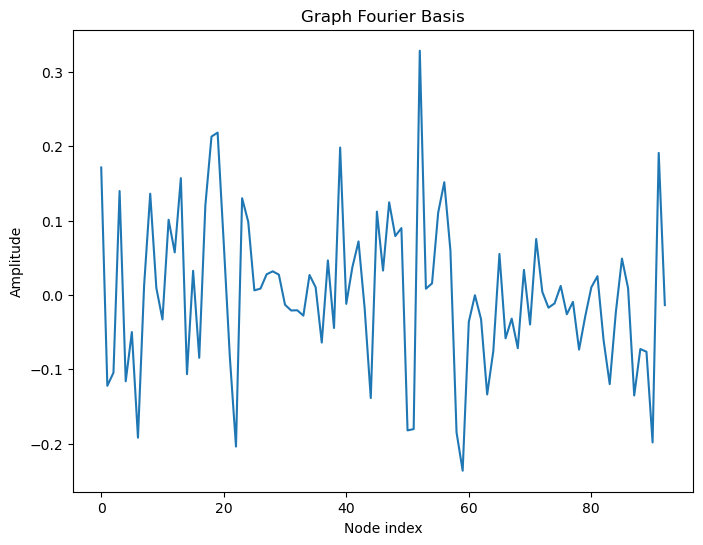

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Define your graph (adjacency matrix A)
# For demonstration, let's create a simple ring graph
N = 100  # Number of nodes
A = np.zeros((N, N))
for i in range(N):
    A[i, (i + 1) % N] = 1
    A[(i + 1) % N, i] = 1

# Compute the graph Laplacian
D = np.diag(np.sum(A, axis=1))
L = D - A

# Compute the eigenvectors and eigenvalues
_, U = eigh(L)

# Plot the first few graph Fourier basis functions
num_basis = 5
plt.figure(figsize=(8, 6))
#for i in range(1):
plt.plot(combine_matrix[0][:, 185], label=f"Basis {i + 1}")

plt.xlabel("Node index")
plt.ylabel("Amplitude")
plt.title("Graph Fourier Basis")
#plt.legend()
plt.show()


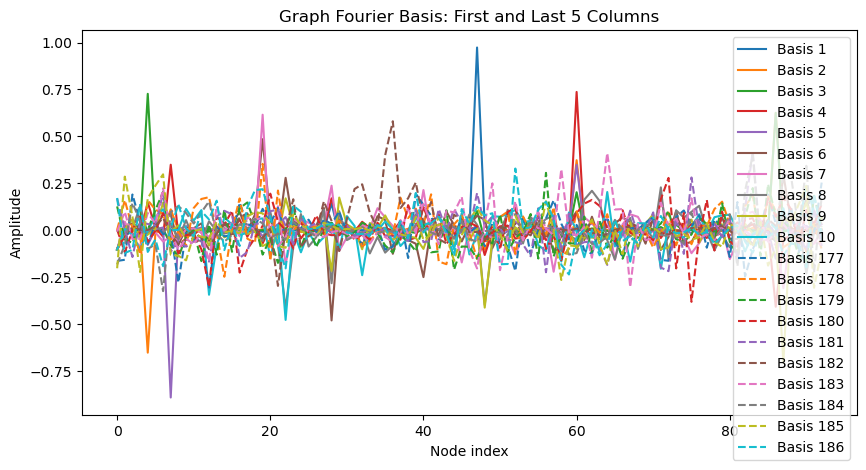

In [104]:
import matplotlib.pyplot as plt

# Assuming 'combine_matrix' is already defined and contains the necessary data
matrix_to_plot = combine_matrix[0]  # This selects the first matrix

# Total columns to be considered
total_columns = matrix_to_plot.shape[1]  # This should be at least 186 based on your loop

# Modify this to handle matrices with fewer than 10 columns
first_columns = 10  # Number of columns from the start
last_columns = 10   # Number of columns from the end

plt.figure(figsize=(10, 5))

# Plot the first 5 columns
for i in range(first_columns):
    plt.plot(matrix_to_plot[:, i], label=f"Basis {i + 1}")

# Plot the last 5 columns
for i in range(total_columns - last_columns, total_columns):
    plt.plot(matrix_to_plot[:, i], linestyle='--', label=f"Basis {i + 1}")

plt.xlabel("Node index")
plt.ylabel("Amplitude")
plt.title("Graph Fourier Basis: First and Last 5 Columns")
plt.legend()

plt.show()


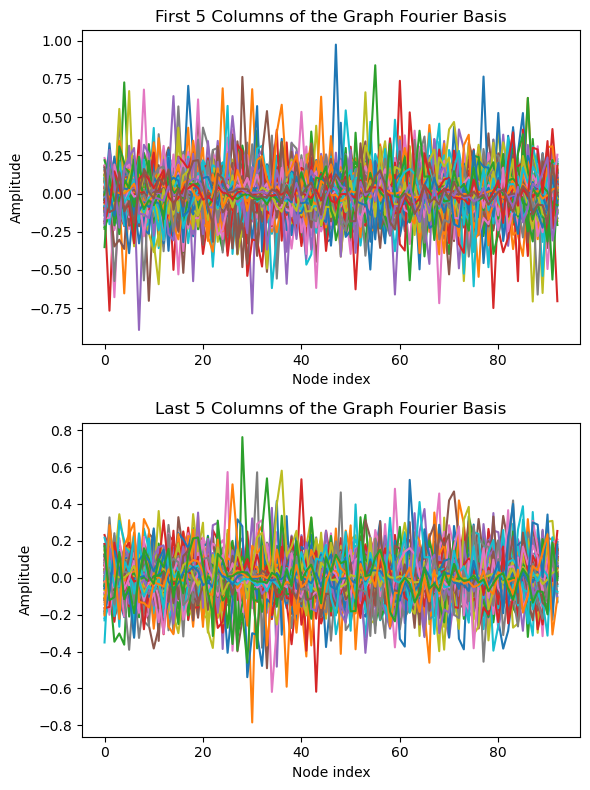

In [116]:
import matplotlib.pyplot as plt

# Assuming 'combine_matrix' is already defined and contains the necessary data
matrix_to_plot = combine_matrix[0]  # This selects the first matrix

# Total columns to be considered
total_columns = matrix_to_plot.shape[1]  # This should be at least 186 based on your loop

# Number of columns from the start and end to plot
first_columns = 186  # Number of columns from the start
last_columns = 93   # Number of columns from the end

# Create a figure with two subplots
plt.figure(figsize=(6, 8))

# First subplot for the first 5 columns
plt.subplot(2, 1, 1)  # (rows, columns, subplot index)
for i in range(first_columns):
    plt.plot(matrix_to_plot[:, i], label=f"Basis {i + 1}")
plt.title("First 5 Columns of the Graph Fourier Basis")
plt.xlabel("Node index")
plt.ylabel("Amplitude")
#plt.legend()

# Second subplot for the last 5 columns
plt.subplot(2, 1, 2)
for i in range(total_columns - last_columns, total_columns):
    plt.plot(matrix_to_plot[:, i], label=f"Basis {i + 1}")
plt.title("Last 5 Columns of the Graph Fourier Basis")
plt.xlabel("Node index")
plt.ylabel("Amplitude")
#plt.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


In [80]:
combine_matrix[0][:,185]

array([ 0.17144241, -0.12216203, -0.10450348,  0.13984666, -0.11611163,
       -0.04987061, -0.19195715,  0.01244018,  0.13620075,  0.00941623,
       -0.03294515,  0.10118402,  0.05721757,  0.15708548, -0.1065571 ,
        0.03254338, -0.08451295,  0.12048871,  0.21302981,  0.2183734 ,
        0.0698832 , -0.08391553, -0.20390953,  0.13010129,  0.09834805,
        0.00616701,  0.00856431,  0.02780059,  0.03179774,  0.02729214,
       -0.01310426, -0.02085354, -0.02057726, -0.02777629,  0.02687432,
        0.01036042, -0.06400825,  0.04649635, -0.04443444,  0.19826653,
       -0.01192638,  0.03747232,  0.07201408, -0.01788647, -0.13862101,
        0.11210448,  0.03282433,  0.12459552,  0.079173  ,  0.08992916,
       -0.18212673, -0.18038045,  0.32846879,  0.00839502,  0.01559684,
        0.11059398,  0.15166494,  0.05983228, -0.18482057, -0.23635215,
       -0.03618998, -0.00033121, -0.03253834, -0.1338057 , -0.07556253,
        0.05515379, -0.05831804, -0.03181729, -0.07154206,  0.03

In [63]:
combine_matrix[0]

array([[-0.10369517, -0.10369517, -0.10369517, ..., -0.1829683 ,
        -0.20326855,  0.17144241],
       [ 0.        ,  0.00884314,  0.005476  , ..., -0.07859655,
         0.2852451 , -0.12216203],
       [ 0.        ,  0.00674518,  0.00404098, ...,  0.14487427,
         0.07235861, -0.10450348],
       ...,
       [ 0.        , -0.00306297, -0.02516956, ...,  0.34296286,
         0.23568103, -0.19832235],
       [ 0.        , -0.00344876, -0.00679389, ..., -0.22730145,
        -0.30737712,  0.19103504],
       [ 0.        ,  0.00580175, -0.00362414, ...,  0.17927326,
        -0.11092577, -0.01361205]])

In [61]:
eu_basis[0]

array([[-0.10369517, -0.10369517, -0.10369517, ..., -0.10369517,
        -0.10369517, -0.10369517],
       [ 0.        ,  0.00884314,  0.005476  , ...,  0.04240462,
        -0.15612528,  0.06330303],
       [ 0.        ,  0.00674518,  0.00404098, ..., -0.01637761,
         0.00234007, -0.0029688 ],
       ...,
       [ 0.        , -0.00306297, -0.02516956, ...,  0.01261029,
         0.08194315,  0.0678511 ],
       [ 0.        , -0.00344876, -0.00679389, ...,  0.09115421,
         0.07628012,  0.00693381],
       [ 0.        ,  0.00580175, -0.00362414, ..., -0.0219968 ,
         0.09987357, -0.0097119 ]])

In [64]:
rem_basis[0]

array([[-0.00870941, -0.04032136,  0.03964235, ..., -0.1829683 ,
        -0.20326855,  0.17144241],
       [ 0.12032485,  0.1148462 ,  0.15557654, ..., -0.07859655,
         0.2852451 , -0.12216203],
       [-0.06048297, -0.08071156,  0.02022677, ...,  0.14487427,
         0.07235861, -0.10450348],
       ...,
       [-0.07089338, -0.03226242, -0.0959764 , ...,  0.34296286,
         0.23568103, -0.19832235],
       [ 0.01450548,  0.03934629, -0.0616497 , ..., -0.22730145,
        -0.30737712,  0.19103504],
       [ 0.11365064,  0.10387398,  0.14033562, ...,  0.17927326,
        -0.11092577, -0.01361205]])

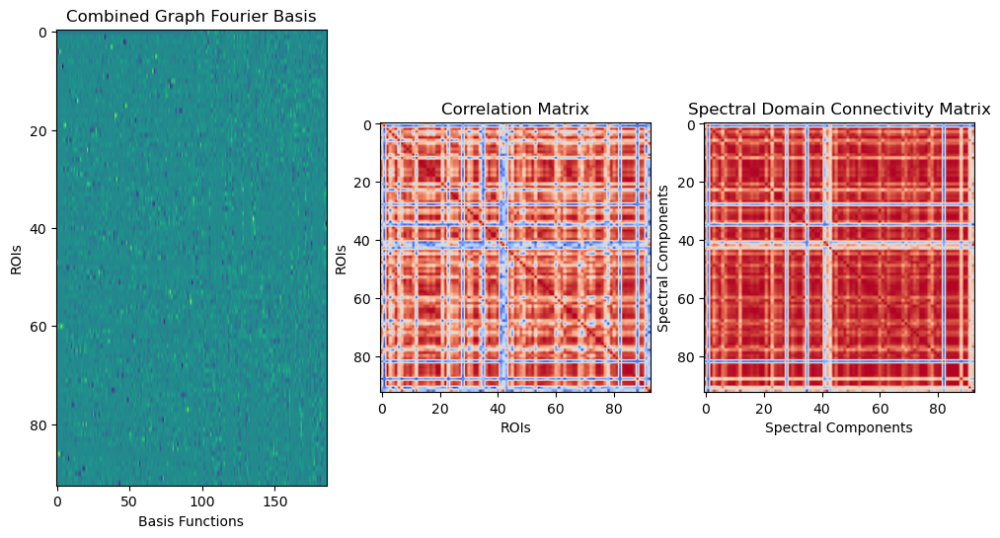

In [115]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Plot Combined GFB
axes[0].imshow(combine_matrix[1], aspect='auto', cmap='viridis')
axes[0].set_title('Combined Graph Fourier Basis')
axes[0].set_xlabel('Basis Functions')
axes[0].set_ylabel('ROIs')

# Plot Correlation Matrix
axes[1].imshow(correlation_matrix[1], cmap='coolwarm')
axes[1].set_title('Correlation Matrix')
axes[1].set_xlabel('ROIs')
axes[1].set_ylabel('ROIs')

# Plot Spectral Domain Connectivity Matrix
axes[2].imshow(fc_matrix[1], cmap='coolwarm')
axes[2].set_title('Spectral Domain Connectivity Matrix')
axes[2].set_xlabel('Spectral Components')
axes[2].set_ylabel('Spectral Components')

plt.show()


In [119]:
projected_data[0].shape

(93, 186)

Text(0, 0.5, 'ROIs')

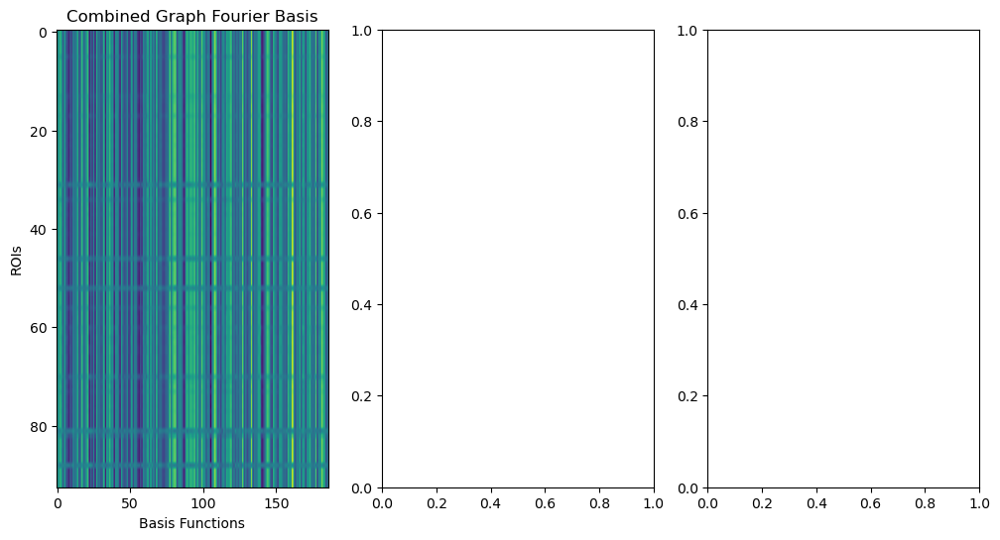

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Plot Combined GFB
axes[0].imshow(projected_data[0], aspect='auto', cmap='viridis')
axes[0].set_title('Combined Graph Fourier Basis')
axes[0].set_xlabel('Basis Functions')
axes[0].set_ylabel('ROIs')